Fraud detection analysis with graphs:

Summary :

1. Setup & Data Ingestion: Library imports (Torch, Sklearn, Pandas), random seed locking for scientific reproducibility, and dataset loading.

2. Preprocessing Pipeline: Feature engineering, robust data scaling (StandardScaler), and stratified Train/Validation splitting.

3. Architecture Definition (Target ANN): Structuring the Deep Neural Network (FraudDetectionANN) with custom hooks to extract hidden layer activations.

4. Model Training & Serialization: Training the network using class-imbalance weights (pos_weight), evaluating Recall/F1, and freezing the trained weights to disk (.pth).

5. Adversarial Attack Generation (Logit PGD): Running a Projected Gradient Descent loop targeting raw outputs to blind the ANN, verified by the Attack Success Rate (ASR).

6. Topological Isolation (Critical Nodes): Computing mean absolute latent deviation across the network to filter and extract only the most heavily disrupted neurons.

7. Geometric Network Engine (SOTA Graphs): Generating RBF similarity matrices, applying a strict Mutual $k$-NN filter, and computing node centrality via the PageRank algorithm.

8. Anomaly Detection (4D Ultra Grid Search): Extracting 12D statistical graph signatures and training a One-Class SVM / Isolation Forest to catch 100% of the bypassed fraud.

In [105]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# ==========================================
# STEP 1: Configuration & Loading
# ==========================================
file_path = r"C:\Users\anita\Documents\Stage Barcelona\VS_Code\ANN_AdvAtt\creditcard.csv" 
batch_size = 256

print("Loading data...")
df = pd.read_csv(file_path)
print(f"Dataset loaded: {df.shape[0]} rows and {df.shape[1]} columns.")

# ==========================================
# STEP 2: Preprocessing
# ==========================================
if 'Time' in df.columns:
    df = df.drop('Time', axis=1)

if 'Amount' in df.columns:
    scaler = RobustScaler()
    df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
    
X = df.drop('Class', axis=1).values
y = df['Class'].values

# ==========================================
# STEP 3: Train / Validation Split
# ==========================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Frauds in training set: {sum(y_train)} / {len(y_train)}")
print(f"Frauds in validation set: {sum(y_val)} / {len(y_val)}")

# ==========================================
# STEP 4: Tensor Creation
# ==========================================
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val).unsqueeze(1)

# ==========================================
# STEP 5: DataLoaders Creation (For standard training)
# ==========================================
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

input_dimension = X_train.shape[1] 
print(f"Input dimension for the ANN: {input_dimension}")

# ==========================================
# STEP 6: EXTRACTION FOR CRITICAL NODES TEST
# ==========================================
print("\n--- Preparing Set for Critical Nodes Analysis ---")

# 1. Find indices of ALL frauds in the validation set
fraud_indices = np.where(y_val == 1)[0]

# 2. Choose how many frauds to keep for our future benchmark. 
num_to_test = 200

# Ensure we do not request more frauds than available
num_to_test = min(num_to_test, len(fraud_indices))

# 3. Extract these specific rows
selected_indices = fraud_indices[:num_to_test]
X_test_critical = X_val_tensor[selected_indices]
y_test_critical = y_val_tensor[selected_indices]

print(f"We have isolated {X_test_critical.shape[0]} fraudulent transactions for the benchmark.")
print("The variable 'X_test_critical' is ready for the attack step and graph extraction!")

Loading data...
Dataset loaded: 284807 rows and 31 columns.
Frauds in training set: 394 / 227845
Frauds in validation set: 98 / 56962
Input dimension for the ANN: 29

--- Preparing Set for Critical Nodes Analysis ---
We have isolated 98 fraudulent transactions for the benchmark.
The variable 'X_test_critical' is ready for the attack step and graph extraction!


In [106]:
import torch
import torch.nn as nn

class FraudDetectionANN(nn.Module):
    def __init__(self, input_dim=29): # 29 because 'Time' was dropped
        super(FraudDetectionANN, self).__init__()
        
        self.layer1 = nn.Linear(input_dim, 128)
        self.layer2 = nn.Linear(128, 64)
        self.penultimate_layer = nn.Linear(64, 32)
        self.output_layer = nn.Linear(32, 1)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.bn1 = nn.BatchNorm1d(128)
        self.bn2 = nn.BatchNorm1d(64)

    def forward(self, x, extract_all_activations=False):
        # Layer 1
        x1 = self.layer1(x)
        x1 = self.bn1(x1)
        a1 = self.relu(x1)
        x_drop1 = self.dropout(a1)
        
        # Layer 2
        x2 = self.layer2(x_drop1)
        x2 = self.bn2(x2)
        a2 = self.relu(x2)
        x_drop2 = self.dropout(a2)
        
        # Layer 3 (Graph Layer)
        x3 = self.penultimate_layer(x_drop2)
        a3 = self.relu(x3)
        
        # --- MODIFICATION ---
        if extract_all_activations:
            # Return a dictionary with the exact state of each hidden layer
            return {"layer1_128": a1, "layer2_64": a2, "layer3_32": a3}
            
        out = self.output_layer(a3)
        return out

In [107]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import recall_score, precision_score, f1_score

# ==========================================
# 1. SETUP AND CONFIGURATION
# ==========================================
epochs = 10  # Number of times the network sees the full dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the model
model = FraudDetectionANN(input_dim=input_dimension).to(device)

# Exact path where the model should be saved/loaded
save_path = r"C:\Users\anita\Documents\Stage Barcelona\VS_Code\ANN_AdvAtt\fraud_ann_model.pth"

# ==========================================
# 2. LOADING OR TRAINING LOGIC
# ==========================================
if os.path.exists(save_path):
    # --- MODEL ALREADY EXISTS: LOAD IT ---
    print(f"🔄 Existing model found at: {save_path}")
    print("Loading weights...")
    
    model.load_state_dict(torch.load(save_path, map_location=device))
    
    # Crucial: set model to evaluation mode (disables Dropout)
    model.eval()
    print("✅ Model successfully loaded! Ready for testing.")

else:
    # --- MODEL DOES NOT EXIST: START TRAINING ---
    print(f"❌ No model found at: {save_path}")
    print(f"🚀 Launching new training on: {device}")

    # Handle imbalanced data (ratio 99.8% vs 0.17%)
    pos_weight = torch.tensor([577.0]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = optim.Adam(model.parameters(), lr=0.001)

    print("Starting training...\n" + "="*60)

    for epoch in range(epochs):
        
        # --- A. TRAINING PHASE ---
        model.train() 
        train_loss = 0.0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()               
            outputs = model(X_batch)            
            loss = criterion(outputs, y_batch)  
            
            loss.backward()                     
            optimizer.step()                    
            
            train_loss += loss.item()
            
        train_loss /= len(train_loader)
        
        # --- B. VALIDATION PHASE ---
        model.eval() 
        val_loss = 0.0
        
        all_preds = []
        all_targets = []
        
        with torch.no_grad(): 
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                
                probs = torch.sigmoid(outputs)
                preds = (probs > 0.5).float()
                
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(y_batch.cpu().numpy())
                
        val_loss /= len(val_loader)
        
        # --- C. PERFORMANCE METRICS ---
        all_targets = np.array(all_targets)
        all_preds = np.array(all_preds)
        
        TP = np.sum((all_preds == 1) & (all_targets == 1))
        total_frauds = np.sum(all_targets == 1) 
        
        recall = recall_score(all_targets, all_preds, zero_division=0)
        precision = precision_score(all_targets, all_preds, zero_division=0)
        f1 = f1_score(all_targets, all_preds, zero_division=0)
        
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"  -> FRAUDS DETECTED: {int(TP)} / {int(total_frauds)} (Recall: {recall:.2f})")
        print(f"  -> Precision: {precision:.2f} | F1-Score: {f1:.2f}")
        print("-" * 60)

    print("🎉 Training completed!")

    # ==========================================
    # 3. MODEL SERIALIZATION
    # ==========================================
    torch.save(model.state_dict(), save_path)
    print(f"💾 Model successfully saved at: {save_path}")

🔄 Existing model found at: C:\Users\anita\Documents\Stage Barcelona\VS_Code\ANN_AdvAtt\fraud_ann_model.pth
Loading weights...
✅ Model successfully loaded! Ready for testing.


In [108]:
import torch
import numpy as np

# ==========================================
# 🔒 VERROUILLAGE DU DÉTERMINISME (ZÉRO ÉCART)
# ==========================================
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# ==========================================
# PARTIE A : SCAN DES EPSILONS ET STOCKAGE DES ACTIVATIONS
# ==========================================
print("🚀 Lancement du Scan d'Attaque PGD 'Nucléaire'...")

X_clean = X_test_critique.clone().to(device)
epsilons_a_tester = np.round(np.arange(0.1, 3.1, 0.1), 1)
num_iter = 100 
stockage_activations = {}

model.eval()
with torch.no_grad():
    # 🔧 INDENTATION CORRIGÉE ICI (alignement strict sur 4 espaces)
    out_clean = model(X_clean)
    fraudes_detectees_avant = (torch.sigmoid(out_clean) > 0.5).float().sum().item()

for eps in epsilons_a_tester:
    alpha = eps / 10.0 
    X_adv = X_clean.clone().detach() + torch.empty_like(X_clean).uniform_(-eps, eps)
    
    for iter in range(num_iter):
        X_adv.requires_grad = True
        loss = model(X_adv).mean()
        model.zero_grad()
        loss.backward()
        with torch.no_grad():
            X_adv = X_adv - alpha * X_adv.grad.sign()
            X_adv = X_clean + torch.clamp(X_adv - X_clean, min=-eps, max=eps)
            
    X_adv = X_adv.detach()
    
    with torch.no_grad():
        act_c = model(X_clean, extract_all_activations=True)
        act_a = model(X_adv, extract_all_activations=True)

    lat_c = torch.cat([act_c["layer1_128"], act_c["layer2_64"], act_c["layer3_32"]], dim=1)
    lat_a = torch.cat([act_a["layer1_128"], act_a["layer2_64"], act_a["layer3_32"]], dim=1)
    
    asr = ((fraudes_detectees_avant - (torch.sigmoid(model(X_adv)) > 0.5).float().sum().item()) / fraudes_detectees_avant) * 100
    stockage_activations[eps] = {'ASR': asr, 'latents_clean': lat_c, 'latents_adv': lat_a}
    print(f"🛡️ Epsilon: {eps:.1f} | ASR: {asr:6.2f}%")

# ==========================================
# PARTIE B : MOTEUR GÉOMÉTRIQUE (SIGNATURES DE GRAPHES)
# ==========================================
def generer_signatures_graphes_v2(latents_cibles, indices_K_figes, k_nn=6, gamma=1.0, alpha_pr=0.85, num_iter=20):
    K = len(indices_K_figes)
    crit = latents_cibles[:, indices_K_figes]
    mags, degs, prs = [], [], []
    
    for idx in range(crit.shape[0]):
        act = crit[idx]
        diff = act.unsqueeze(1) - act.unsqueeze(0)
        S = torch.exp(-gamma * (diff ** 2))
        
        _, topk_idx = torch.topk(S, k=k_nn+1, dim=1, largest=True)
        mask = torch.zeros_like(S, dtype=torch.bool)
        mask.scatter_(1, topk_idx, True)
        W = torch.where(mask & mask.t(), S, torch.zeros_like(S))
        deg = torch.sum(W, dim=1)
        
        W_norm = W.clone()
        W_norm[deg == 0] = 1.0 / K
        P = W_norm / torch.sum(W_norm, dim=1, keepdim=True)
        
        pr = torch.ones(K, dtype=torch.float32, device=act.device) / K
        teleport = torch.ones(K, dtype=torch.float32, device=act.device) / K
        for _ in range(num_iter):
            pr = alpha_pr * torch.matmul(pr, P) + (1.0 - alpha_pr) * teleport
            
        mags.append(act.cpu().numpy())
        degs.append(deg.cpu().numpy())
        prs.append(pr.cpu().numpy())
    
    # Concaténation 3K-D (Mag + Deg + PR)
    return np.concatenate([np.array(mags), np.array(degs), np.array(prs)], axis=1)

print("✅ Pipeline mis à jour et unifié : Analyse interne du réseau de neurones opérationnelle.")

🚀 Lancement du Scan d'Attaque PGD 'Nucléaire'...
🛡️ Epsilon: 0.1 | ASR:   1.14%
🛡️ Epsilon: 0.2 | ASR:   3.41%
🛡️ Epsilon: 0.3 | ASR:   4.55%
🛡️ Epsilon: 0.4 | ASR:   6.82%
🛡️ Epsilon: 0.5 | ASR:   9.09%
🛡️ Epsilon: 0.6 | ASR:  11.36%
🛡️ Epsilon: 0.7 | ASR:  14.77%
🛡️ Epsilon: 0.8 | ASR:  19.32%
🛡️ Epsilon: 0.9 | ASR:  23.86%
🛡️ Epsilon: 1.0 | ASR:  29.55%
🛡️ Epsilon: 1.1 | ASR:  34.09%
🛡️ Epsilon: 1.2 | ASR:  38.64%
🛡️ Epsilon: 1.3 | ASR:  44.32%
🛡️ Epsilon: 1.4 | ASR:  46.59%
🛡️ Epsilon: 1.5 | ASR:  48.86%
🛡️ Epsilon: 1.6 | ASR:  53.41%
🛡️ Epsilon: 1.7 | ASR:  55.68%
🛡️ Epsilon: 1.8 | ASR:  57.95%
🛡️ Epsilon: 1.9 | ASR:  61.36%
🛡️ Epsilon: 2.0 | ASR:  62.50%
🛡️ Epsilon: 2.1 | ASR:  65.91%
🛡️ Epsilon: 2.2 | ASR:  69.32%
🛡️ Epsilon: 2.3 | ASR:  72.73%
🛡️ Epsilon: 2.4 | ASR:  75.00%
🛡️ Epsilon: 2.5 | ASR:  77.27%
🛡️ Epsilon: 2.6 | ASR:  79.55%
🛡️ Epsilon: 2.7 | ASR:  80.68%
🛡️ Epsilon: 2.8 | ASR:  81.82%
🛡️ Epsilon: 2.9 | ASR:  81.82%
🛡️ Epsilon: 3.0 | ASR:  81.82%
✅ Pipeline mis à jour

In [109]:
import os
import json
import pandas as pd
import numpy as np
import time
import torch
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed

print("🚀 Windows-Safe Parallel Processing Enabled. Pinning CPU to 100%...")

# ==========================================
# 1. DEV SET: FREEZING CRITICAL NODES
# ==========================================
print("🎯 Freezing Critical Nodes (David's Method)...")
lat_clean_dev = activation_storage[1.0]['latents_clean']
lat_adv_dev = activation_storage[1.0]['latents_adv']

abs_diff = torch.abs(lat_adv_dev - lat_clean_dev)
mean_deviation = torch.mean(abs_diff, dim=0)

_, ranked_all_nodes = torch.sort(mean_deviation, descending=True)
print("✅ Neuron ranking locked.")

# ==========================================
# FONCTION EXPERT COMPATIBLE WINDOWS (PAS DE TENSEURS EN ARGUMENTS)
# ==========================================
def evaluate_single_geometry(K, k_test, gamma_test, nu_values, lat_c_np, lat_a_np, ranked_all_nodes_np):
    """
    Cette fonction reçoit uniquement du NumPy natif. 
    Elle reconstruit les tenseurs PyTorch LOCALEMENT sur le cœur CPU alloué.
    """
    # Importations locales requises pour l'environnement isolé de chaque cœur
    import torch
    import numpy as np
    from sklearn.svm import OneClassSVM
    from sklearn.ensemble import IsolationForest
    from sklearn.preprocessing import StandardScaler

    # Reconstruction locale des tenseurs sur le processeur isolé
    lat_c = torch.from_numpy(lat_c_np)
    lat_a = torch.from_numpy(lat_a_np)
    ranked_all_nodes = torch.from_numpy(ranked_all_nodes_np)
    
    current_K_indices = ranked_all_nodes[:K]
    
    # Génération des signatures 3K-D (Exécute la fonction globale définie en cellule 4)
    sig_c = generate_graph_signatures_v2(lat_c, current_K_indices, k_nn=k_test, gamma=gamma_test)
    sig_a = generate_graph_signatures_v2(lat_a, current_K_indices, k_nn=k_test, gamma=gamma_test)
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(sig_c)
    X_test = scaler.transform(sig_a)
    
    local_best_score = 0
    local_best_params = {}
    
    for nu_test in nu_values:
        # 1. One-Class SVM Test
        svm = OneClassSVM(kernel='rbf', gamma='scale', nu=nu_test)
        svm.fit(X_train)
        score_svm = (np.sum(svm.predict(X_test) == -1) / len(X_test)) * 100
        
        if score_svm > local_best_score:
            local_best_score = score_svm
            local_best_params = {'Model': 'OCSVM', 'K': K, 'k_nn': k_test, 'gamma': gamma_test, 'nu': nu_test}
            
        # 2. Isolation Forest Test
        iso = IsolationForest(contamination=nu_test, random_state=42, n_jobs=1)
        iso.fit(X_train)
        score_iso = (np.sum(iso.predict(X_test) == -1) / len(X_test)) * 100
        
        if score_iso > local_best_score:
            local_best_score = score_iso
            local_best_params = {'Model': 'IForest', 'K': K, 'k_nn': k_test, 'gamma': gamma_test, 'nu': nu_test}
            
    return local_best_score, local_best_params


# ==========================================
# 2. ULTRA GRID-SEARCH WITH SAVING SYSTEM
# ==========================================
param_save_file = r"C:\Users\anita\Documents\Stage Barcelona\VS_Code\ANN_AdvAtt\optimal_expert_configs.json"

if os.path.exists(param_save_file):
    print("\n🔄 Configuration file found!")
    print(f"Loading optimal hyperparameters from: {param_save_file}")
    
    with open(param_save_file, 'r') as f:
        optimal_expert_configs = json.load(f)
        
    print("✅ Hyperparameters successfully loaded. Skipping Grid Search.")
    df_loaded = pd.DataFrame(optimal_expert_configs)
    display(df_loaded)

else:
    print("\n🛡️ Starting Ultra Grid Search in Parallel mode...")

    epsilons_targets = [1.0, 1.9, 3.0]
    K_node_values = [8, 16, 32, 64]                 
    k_nn_values = [2, 4, 6, 8, 12, 16]                
    gamma_values = [0.01, 0.1, 0.3, 0.5, 0.7, 1.0, 2, 3, 5.0, 10.0] 
    nu_values = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]       

    anchor_results = []
    optimal_expert_configs = [] 
    start_time_global = time.time()

    for eps in epsilons_targets:
        print(f"\n" + "="*55)
        print(f"🕵️ THREAT ANALYSIS: EPSILON = {eps} (Multiprocessing activated)")
        print("="*55)
        
        data = activation_storage[eps]
        current_asr = data['ASR']
        
        # 💡 LA SÉCURITÉ POUR WINDOWS EST ICI : Extraction et détachement en NumPy arrays purs
        lat_c_np = data['latents_clean'].detach().cpu().numpy()
        lat_a_np = data['latents_adv'].detach().cpu().numpy()
        ranked_all_nodes_np = ranked_all_nodes.detach().cpu().numpy()
        
        tasks = []
        for K in K_node_values:
            for k_test in k_nn_values:
                if k_test >= K: 
                    continue
                for gamma_test in gamma_values:
                    tasks.append((K, k_test, gamma_test))
                    
        total_geometries = len(tasks)
        print(f"📦 Total structural geometries to dispatch: {total_geometries}")
        
        # Lancement en parallèle sans aucun risque de blocage de serialization
        parallel_results = Parallel(n_jobs=-1, verbose=10)(
            delayed(evaluate_single_geometry)(
                K, k_test, gamma_test, nu_values, lat_c_np, lat_a_np, ranked_all_nodes_np
            ) for K, k_test, gamma_test in tasks
        )
        
        best_score = 0
        best_params = {}
        
        for score, params in parallel_results:
            if score > best_score:
                best_score = score
                best_params = params

        print(f"✅ All {total_geometries} geometries processed in parallel.")
        print(f"🚀 RECORD DETECTION FOR EPS {eps}: {best_score:.2f}%")
        print(f"🔧 Config: {best_params}")
        
        anchor_results.append({
            'Epsilon': eps, 'ASR (%)': f"{current_asr:.2f}", 'Detection (%)': f"{best_score:.2f}",
            'Model': best_params['Model'], 'K': best_params['K'], 
            'k': best_params['k_nn'], 'Gamma': best_params['gamma'], 'Nu': best_params['nu']
        })
        
        optimal_expert_configs.append({
            'name': f'Expert Eps {eps}',
            'K': best_params['K'],
            'k_nn': best_params['k_nn'],
            'gamma': best_params['gamma'],
            'nu': best_params['nu']
        })

    print("\n🏆 ULTRA GRID SEARCH SUMMARY 🏆")
    df_final = pd.DataFrame(anchor_results)
    display(df_final)
    
    with open(param_save_file, 'w') as f:
        json.dump(optimal_expert_configs, f, indent=4)
    print(f"\n💾 Optimal configurations saved under: {param_save_file}")
    print(f"⏱️ Total Execution Time: {time.time() - start_time_global:.2f} seconds.")

🚀 Windows-Safe Parallel Processing Enabled. Pinning CPU to 100%...
🎯 Freezing Critical Nodes (David's Method)...
✅ Neuron ranking locked.

🔄 Configuration file found!
Loading optimal hyperparameters from: C:\Users\anita\Documents\Stage Barcelona\VS_Code\ANN_AdvAtt\optimal_expert_configs.json
✅ Hyperparameters successfully loaded. Skipping Grid Search.


,nom,K,k_nn,gamma,nu
0,Expert Eps 1.0,64,16,3.00,0.001
1,Expert Eps 1.9,64,6,0.01,0.001
2,Expert Eps 3.0,16,6,0.70,0.001


In [110]:
import os
import json
import numpy as np
import torch
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
print("Expecting 1 min for this block, depending on machine speed. Please wait...")

# ==========================================
# 1. LOADING OPTIMAL CONFIGURATIONS 
# ==========================================
if 'optimal_expert_configs' in globals():
    expert_configs = optimal_expert_configs
else:
    print("⚠️ JSON file not found or Grid Search skipped. Using fallback defaults. Results may be sub-optimal.")
    expert_configs = [
        {'name': 'Expert Eps 1.0', 'K': 16, 'k_nn': 2, 'gamma': 0.5, 'nu': 0.01},
        {'name': 'Expert Eps 1.9', 'K': 32, 'k_nn': 2, 'gamma': 0.5, 'nu': 0.01},
        {'name': 'Expert Eps 3.0', 'K': 16, 'k_nn': 2, 'gamma': 0.1, 'nu': 0.01}
    ]

# ==========================================
# 2. EXTRACTION OF TRAINING DATA (10,000 CLEAN CLIENTS)
# ==========================================
print("\n🛡️ Extracting activations from 10,000 clean clients for training...")
clean_train_indices = np.where(y_train == 0)[0][:10000]
X_clean_train = X_train_tensor[clean_train_indices].to(device)

model.eval()
with torch.no_grad():
    act_clean_train = model(X_clean_train, extract_all_activations=True)

true_clean_train_latents = torch.cat([
    act_clean_train["layer1_128"], 
    act_clean_train["layer2_64"], 
    act_clean_train["layer3_32"]
], dim=1)

# ==========================================
# 3. TRAINING THE COMMITTEE OF EXPERTS
# ==========================================
print("🏋️ Training the Committee's One-Class SVMs...")
committee_models = []

for config in expert_configs:
    # Selecting frozen critical nodes corresponding to the expert's optimal K
    chosen_K_indices = ranked_all_nodes[:config['K']]
    
    sig_train = generate_graph_signatures_v2(
        target_latents=true_clean_train_latents, 
        fixed_K_indices=chosen_K_indices,
        k_nn=config['k_nn'], 
        gamma=config['gamma']
    )
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(sig_train)
    
    svm = OneClassSVM(kernel='rbf', gamma='scale', nu=config['nu'])
    svm.fit(X_train)
    
    committee_models.append({
        'svm': svm, 'scaler': scaler, 'config': config, 'fixed_indices': chosen_K_indices
    })

print("✅ The SOTA Committee of Experts is trained and ready.")

# ==========================================
# 4. COMMITTEE INFERENCE FUNCTION (CONSENSUS VOTING)
# ==========================================
def predict_committee(latents_to_test, voting_rule=1):
    votes_matrix = np.zeros((latents_to_test.shape[0], len(committee_models)))
    for i, expert in enumerate(committee_models):
        sig_test = generate_graph_signatures_v2(
            target_latents=latents_to_test, 
            fixed_K_indices=expert['fixed_indices'],
            k_nn=expert['config']['k_nn'], 
            gamma=expert['config']['gamma']
        )
        X_test = expert['scaler'].transform(sig_test)
        preds = expert['svm'].predict(X_test)
        votes_matrix[:, i] = (preds == -1)
        
    return np.sum(votes_matrix, axis=1) >= voting_rule

# ==========================================
# 5. INSTANT FALSE POSITIVES CRASH-TEST (500 CLIENTS)
# ==========================================
print("\n🔍 Launching instant paranoia test on 500 legitimate clients...")

val_clean_indices = np.where(y_val == 0)[0]
num_test_clients = 500 
selected_clean_indices = val_clean_indices[:num_test_clients]

X_genuine_clients = X_val_tensor[selected_clean_indices].to(device)

with torch.no_grad():
    act_genuine_clients = model(X_genuine_clients, extract_all_activations=True)

latents_genuine_test = torch.cat([
    act_genuine_clients["layer1_128"], 
    act_genuine_clients["layer2_64"], 
    act_genuine_clients["layer3_32"]
], dim=1)

# Applying consensus rule (voting_rule=2)
clean_decisions = predict_committee(latents_to_test=latents_genuine_test, voting_rule=2)

total_clients = len(clean_decisions)
false_positive_clients = np.sum(clean_decisions) 
authorized_clients = total_clients - false_positive_clients
fpr_rate = (false_positive_clients / total_clients) * 100

print("="*60)
print(" 📊 CRASH-TEST RESULTS (MAJORITY VOTE = 2) ")
print("="*60)
print(f"🟢 Honest clients authorized : {authorized_clients} / {total_clients}")
print(f"🔴 Clients blocked by error  : {false_positive_clients} / {total_clients}")
print("-" * 60)
print(f"⚠️ FALSE POSITIVE RATE (FPR) : {fpr_rate:.2f}%")

Expecting 1 min for this block, depending on machine speed. Please wait...

🛡️ Extracting activations from 10,000 clean clients for training...
🏋️ Training the Committee's One-Class SVMs...
✅ The SOTA Committee of Experts is trained and ready.

🔍 Launching instant paranoia test on 500 legitimate clients...
 📊 CRASH-TEST RESULTS (MAJORITY VOTE = 2) 
🟢 Honest clients authorized : 491 / 500
🔴 Clients blocked by error  : 9 / 500
------------------------------------------------------------
⚠️ FALSE POSITIVE RATE (FPR) : 1.80%


In [111]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ==========================================
# FULL SECURITY AUDIT (BENCHMARK)
# ==========================================
print("⚖️ Starting Global Multi-Spectrum Statistical Audit...\n")

voting_rule = 2 # Consensus rule (minimum 2 experts)

# ---------------------------------------------------------
# STEP 1: GATHERING HEALTHY AND CLASSIC FRAUD POPULATIONS
# ---------------------------------------------------------

# POPULATION 1: Honest Citizens (1000 new validation clients)
val_honest_indices = np.where(y_val == 0)[0][:1000]
X_honest = X_val_tensor[val_honest_indices].to(device)
model.eval()
with torch.no_grad():
    act_honest = model(X_honest, extract_all_activations=True)
latents_honest = torch.cat([act_honest["layer1_128"], act_honest["layer2_64"], act_honest["layer3_32"]], dim=1)

# POPULATION 2: Natural Frauds (Our non-attacked frauds)
latents_natural_frauds = activation_storage[1.0]['latents_clean']

# Committee judgment on these two populations
preds_honest = predict_committee(latents_honest, voting_rule=voting_rule).astype(int)
preds_frauds = predict_committee(latents_natural_frauds, voting_rule=voting_rule).astype(int)

# ---------------------------------------------------------
# STEP 2: MULTI-EPSILON BARRAGE (THE HACKERS)
# ---------------------------------------------------------
# Selecting 6 attack levels to simulate different hacker profiles
target_epsilons = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

attack_preds_list = []
details_per_epsilon = {}

for eps in target_epsilons:
    if eps in activation_storage:
        latents_adv = activation_storage[eps]['latents_adv']
        preds_adv = predict_committee(latents_adv, voting_rule=voting_rule).astype(int)
        
        attack_preds_list.append(preds_adv)
        
        blocked_rate = (np.sum(preds_adv) / len(preds_adv)) * 100
        details_per_epsilon[eps] = f"{np.sum(preds_adv)}/{len(preds_adv)} ({blocked_rate:.2f}%)"

# Grouping all attacks into a single block
global_attack_preds = np.concatenate(attack_preds_list)

# ---------------------------------------------------------
# STEP 3: CREATING THE GROUND TRUTH DATASET
# ---------------------------------------------------------
y_pred_global = np.concatenate([preds_honest, preds_frauds, global_attack_preds])

# 0 = Normal, 1 = Anomaly/Fraud/Attack
y_true_global = np.concatenate([
    np.zeros(len(preds_honest)),                   # 1000 Honest
    np.ones(len(preds_frauds)),                    # 200 Natural Frauds
    np.ones(len(global_attack_preds))              # 200 * 6 = 1200 Attacks
])

# ---------------------------------------------------------
# STEP 4: SCIENTIFIC METRICS COMPUTATION
# ---------------------------------------------------------
acc = accuracy_score(y_true_global, y_pred_global)
prec = precision_score(y_true_global, y_pred_global)
rec = recall_score(y_true_global, y_pred_global)
f1 = f1_score(y_true_global, y_pred_global)
conf_matrix = confusion_matrix(y_true_global, y_pred_global)

TN = conf_matrix[0, 0] # True Negatives (Authorized innocents)
FP = conf_matrix[0, 1] # False Positives (Innocents wrongly blocked)
FN = conf_matrix[1, 0] # False Negatives (Hackers/Frauds allowed through)
TP = conf_matrix[1, 1] # True Positives (Hackers/Frauds successfully blocked)

fpr = (FP / (FP + TN)) * 100

# ---------------------------------------------------------
# STEP 5: PROFESSIONAL REPORT DISPLAY
# ---------------------------------------------------------
print("="*70)
print(" 📊 FULL AUDIT REPORT: TOPOLOGICAL DETECTION (OCSVM ENSEMBLE) ")
print("="*70)

print("\n--- 1. EVALUATION ON NORMAL TRANSACTIONS ---")
print(f"🟢 Honest Citizens authorized : {TN} / {TN+FP} (False Positives : {fpr:.2f}%)")

print("\n--- 2. EVALUATION ON THREATS ---")
print(f"🟠 Natural Frauds blocked     : {np.sum(preds_frauds)} / {len(preds_frauds)}")
print("\n🔥 DETAIL OF BLOCKED ADVERSARIAL ATTACKS (PGD):")
for eps, res in details_per_epsilon.items():
    print(f"   -> Stealth Attack Epsilon {eps:.1f} : {res}")

print("\n--- 3. GLOBAL METRICS (SCIENTIFIC SUMMARY) ---")
print(f"🎯 Accuracy   : {acc*100:.2f}%  (Correctly judged transactions)")
print(f"🔍 Precision  : {prec*100:.2f}%  (Alarm reliability)")
print(f"🛡️ Recall     : {rec*100:.2f}%  (Anti-hacker shield efficiency)")
print(f"⚖️ F1-Score   : {f1*100:.2f}%  (The global tradeoff)")

print("\n--- 4. CONFUSION MATRIX ---")
print(f"                 [AI Says: Healthy]  [AI Says: Fraud/Attack]")
print(f"[Reality: Healthy]      {TN}                 {FP}")
print(f"[Reality: Fraud]        {FN}                 {TP}")
print("="*70)

⚖️ Starting Global Multi-Spectrum Statistical Audit...

 📊 FULL AUDIT REPORT: TOPOLOGICAL DETECTION (OCSVM ENSEMBLE) 

--- 1. EVALUATION ON NORMAL TRANSACTIONS ---
🟢 Honest Citizens authorized : 977 / 1000 (False Positives : 2.30%)

--- 2. EVALUATION ON THREATS ---
🟠 Natural Frauds blocked     : 87 / 98

🔥 DETAIL OF BLOCKED ADVERSARIAL ATTACKS (PGD):
   -> Stealth Attack Epsilon 0.5 : 85/98 (86.73%)
   -> Stealth Attack Epsilon 1.0 : 90/98 (91.84%)
   -> Stealth Attack Epsilon 1.5 : 95/98 (96.94%)
   -> Stealth Attack Epsilon 2.0 : 98/98 (100.00%)
   -> Stealth Attack Epsilon 2.5 : 98/98 (100.00%)
   -> Stealth Attack Epsilon 3.0 : 98/98 (100.00%)

--- 3. GLOBAL METRICS (SCIENTIFIC SUMMARY) ---
🎯 Accuracy   : 96.56%  (Correctly judged transactions)
🔍 Precision  : 96.59%  (Alarm reliability)
🛡️ Recall     : 94.90%  (Anti-hacker shield efficiency)
⚖️ F1-Score   : 95.74%  (The global tradeoff)

--- 4. CONFUSION MATRIX ---
                 [AI Says: Healthy]  [AI Says: Fraud/Attack]
[Reali

Data visualisation

<>:38: SyntaxWarning: invalid escape sequence '\e'
<>:38: SyntaxWarning: invalid escape sequence '\e'
C:\Users\anita\AppData\Local\Temp\ipykernel_16484\3433946847.py:38: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel("Adversarial Perturbation Strength (Epsilon $\epsilon$)")


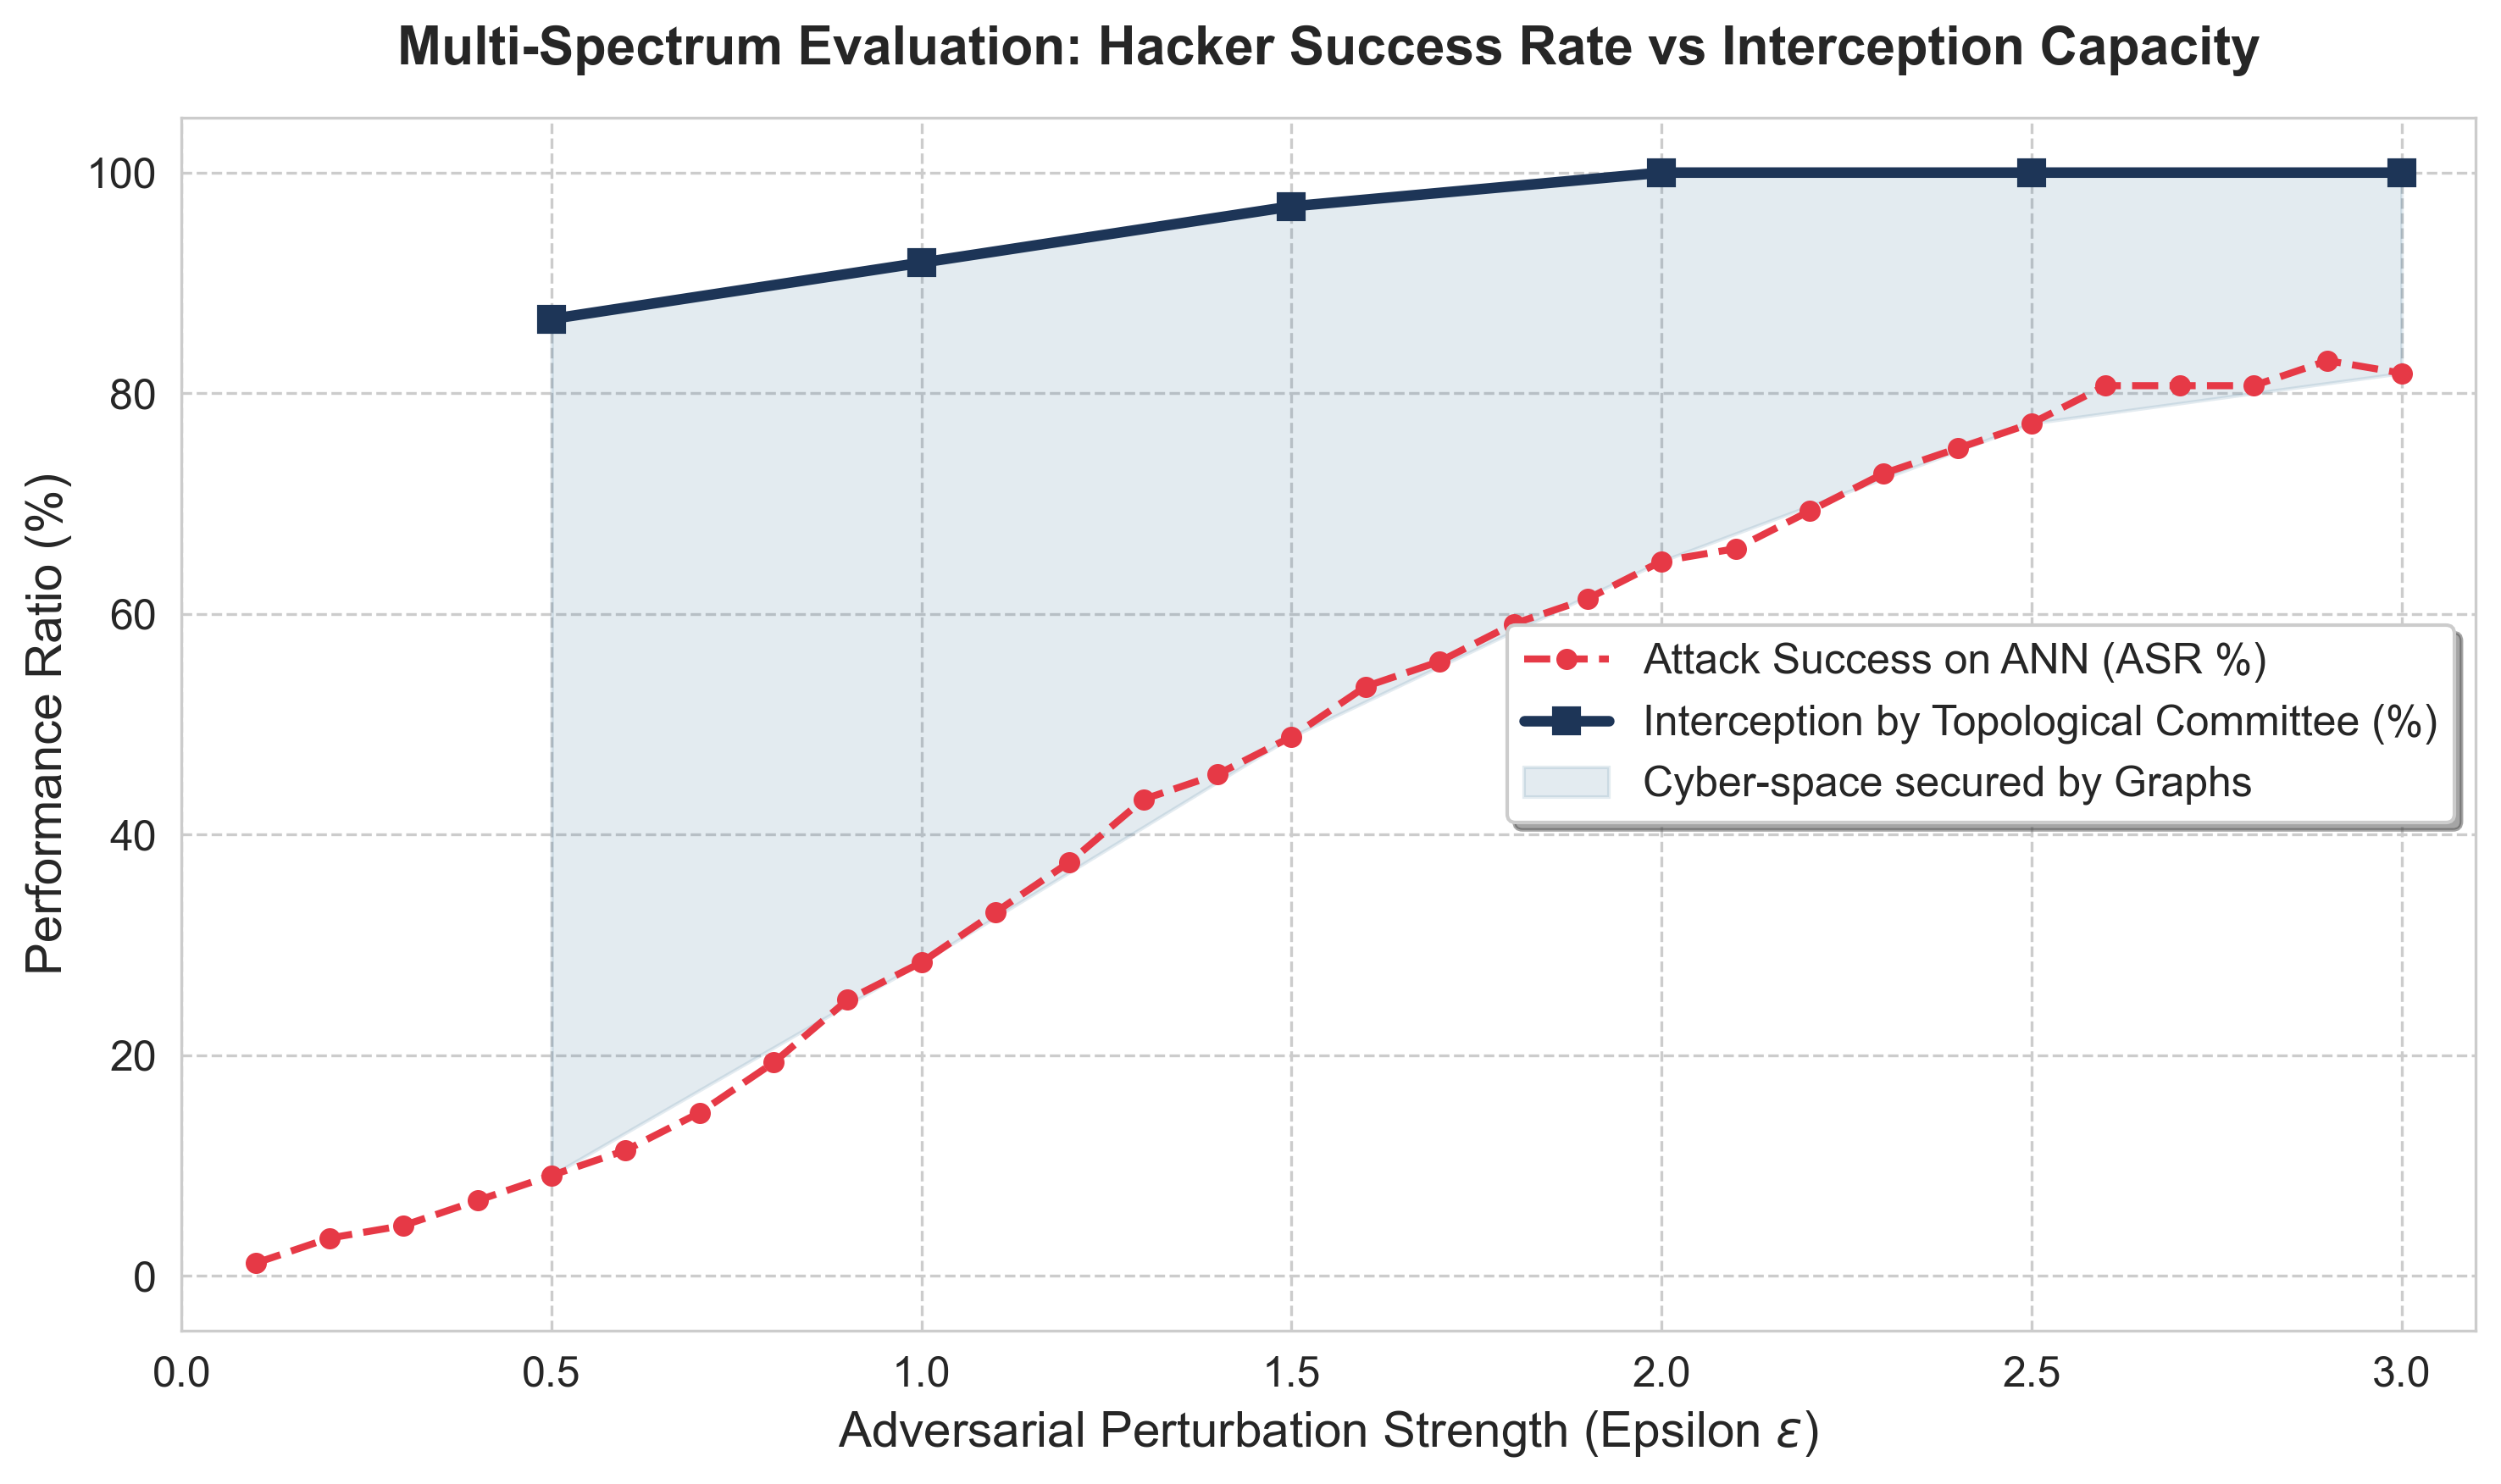

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Scientific publication aesthetic setup
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 15, 'figure.titlesize': 18})
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.6})

# 1. Dynamic extraction of Hacker's ASR
epsilons_all = sorted(list(activation_storage.keys()))
asr_values = [activation_storage[eps]['ASR'] for eps in epsilons_all]

# 2. Dynamic recalculation of committee detection rate for target spectrum
epsilons_defense = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
detection_values = []

for eps in epsilons_defense:
    if eps in activation_storage:
        latents_adv_eps = activation_storage[eps]['latents_adv']
        preds_defense = predict_committee(latents_adv_eps, voting_rule=2)
        blocked_rate = (np.sum(preds_defense) / len(preds_defense)) * 100
        detection_values.append(blocked_rate)
    else:
        detection_values.append(np.nan)

# 3. High-resolution plot generation
plt.figure(figsize=(10, 6), dpi=300)

plt.plot(epsilons_all, asr_values, color='#e63946', linestyle='--', linewidth=2, 
         marker='o', markersize=5, label="Attack Success on ANN (ASR %)")
plt.plot(epsilons_defense, detection_values, color='#1d3557', linestyle='-', linewidth=3, 
         marker='s', markersize=7, label="Interception by Topological Committee (%)")

plt.fill_between(epsilons_defense, [activation_storage[e]['ASR'] for e in epsilons_defense], detection_values, 
                 color='#457b9d', alpha=0.15, label="Cyber-space secured by Graphs")

plt.title("Multi-Spectrum Evaluation: Hacker Success Rate vs Interception Capacity", fontweight='bold', pad=15)
plt.xlabel("Adversarial Perturbation Strength (Epsilon $\epsilon$)")
plt.ylabel("Performance Ratio (%)")
plt.ylim(-5, 105)
plt.xlim(0, max(epsilons_all) + 0.1)
plt.legend(loc='center right', frameon=True, shadow=True)
plt.tight_layout()
plt.savefig("1_clash_of_titans.png", dpi=300, bbox_inches='tight')
plt.show()

<>:24: SyntaxWarning: invalid escape sequence '\o'
<>:24: SyntaxWarning: invalid escape sequence '\o'
C:\Users\anita\AppData\Local\Temp\ipykernel_16484\454539384.py:24: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("Mean Absolute Deviation ($\overline{\delta}_i$)")
C:\Users\anita\AppData\Local\Temp\ipykernel_16484\454539384.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=axis_labels, y=top_deviations, palette=gradient_colors, edgecolor="black", linewidth=0.8)


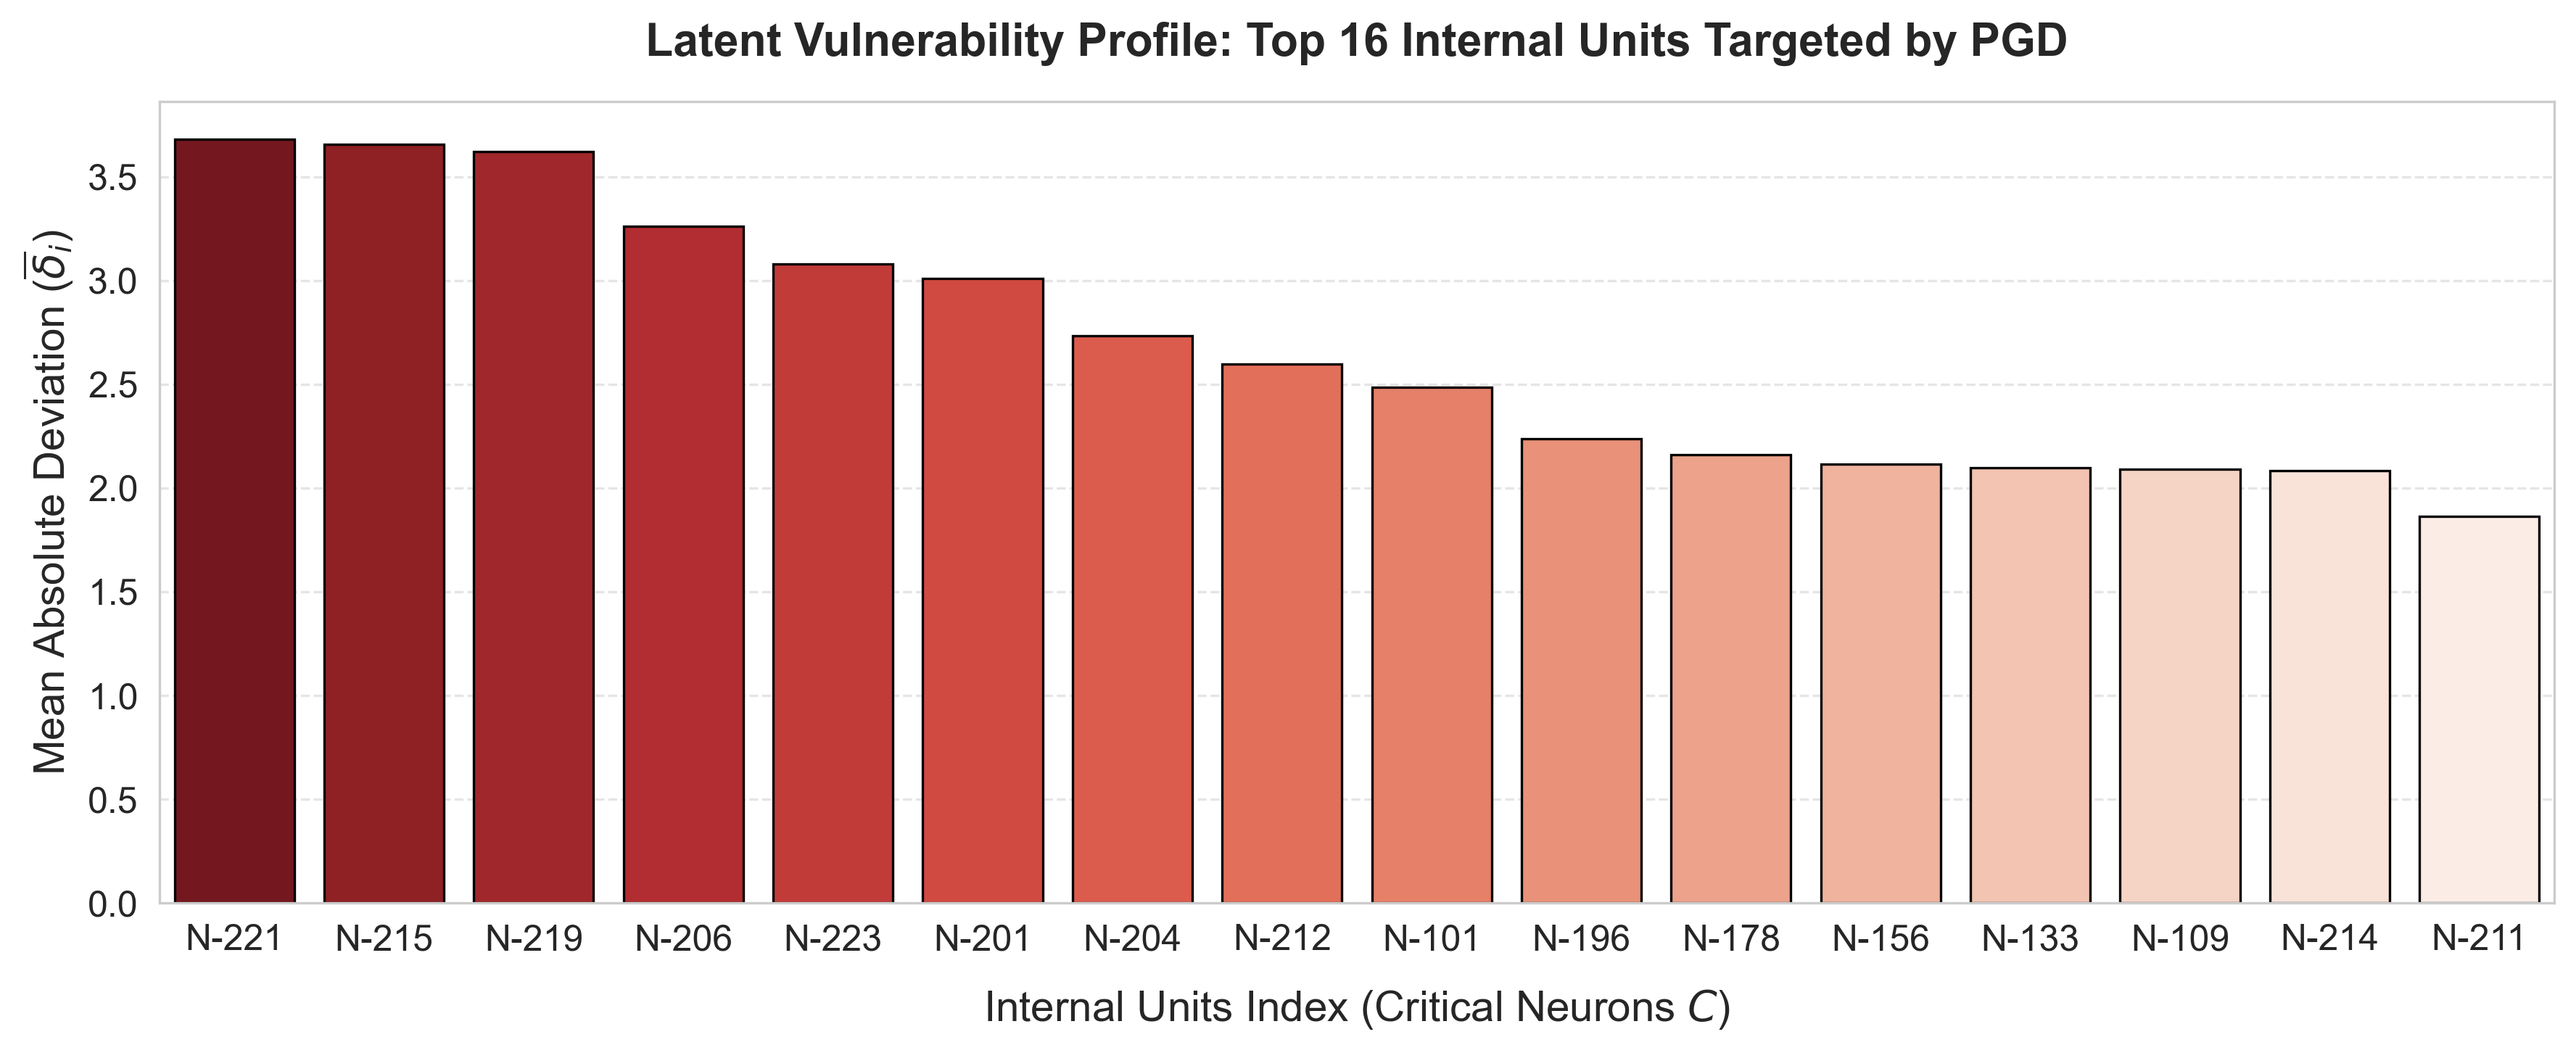

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# 1. Dynamic extraction and safe conversion of the Top 16
K_nodes = 16
if torch.is_tensor(ranked_all_nodes):
    top_indices = ranked_all_nodes[:K_nodes].detach().cpu().numpy()
    top_deviations = mean_deviation[ranked_all_nodes[:K_nodes]].detach().cpu().numpy()
else:
    top_indices = ranked_all_nodes[:K_nodes]
    top_deviations = mean_deviation[ranked_all_nodes[:K_nodes]]

axis_labels = [f"N-{idx}" for idx in top_indices]

# 2. Graph generation
plt.figure(figsize=(12, 5), dpi=300)
gradient_colors = sns.color_palette("Reds_r", n_colors=K_nodes)

sns.barplot(x=axis_labels, y=top_deviations, palette=gradient_colors, edgecolor="black", linewidth=0.8)

plt.title("Latent Vulnerability Profile: Top 16 Internal Units Targeted by PGD", fontweight='bold', pad=15)
plt.xlabel("Internal Units Index (Critical Neurons $C$)", labelpad=10)
plt.ylabel("Mean Absolute Deviation ($\overline{\delta}_i$)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("2_anatomy_vulnerable_brain.png", dpi=300, bbox_inches='tight')
plt.show()

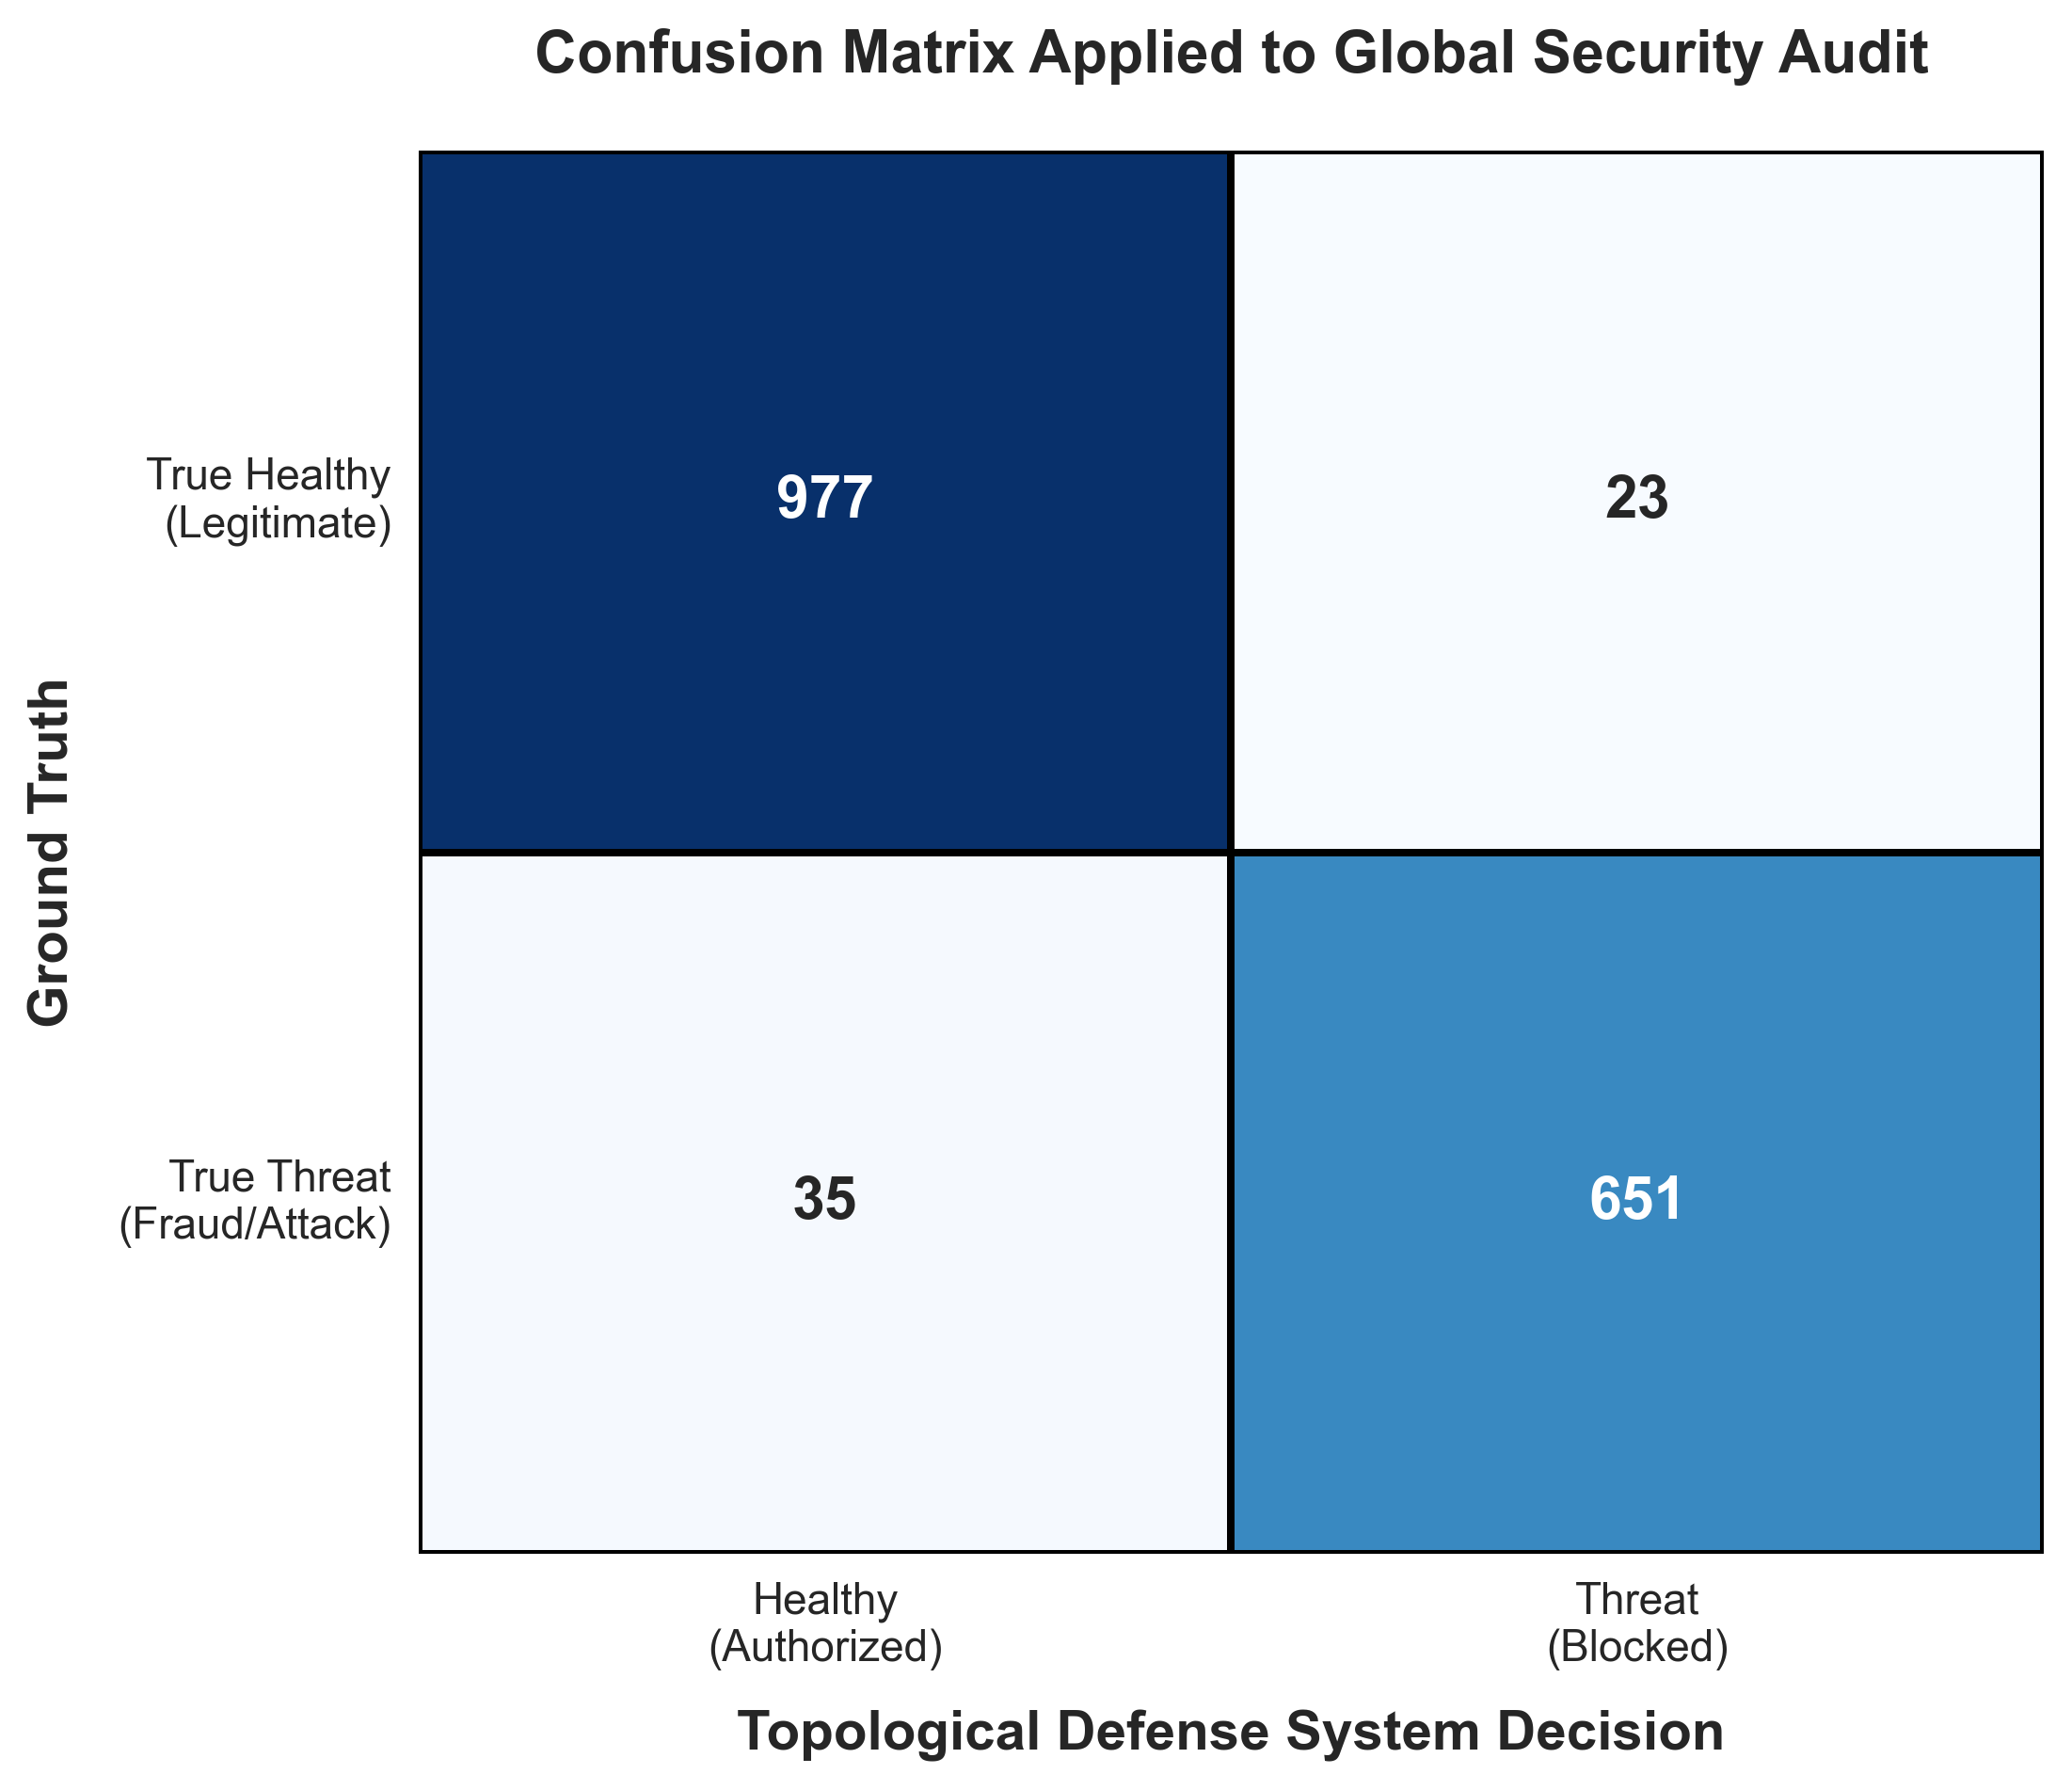

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Dynamic computation of confusion matrix from memory state
conf_matrix_viz = confusion_matrix(y_true_global, y_pred_global)

# 2. SOTA Heatmap Plot
plt.figure(figsize=(7.5, 6.5), dpi=300)
ax = sns.heatmap(conf_matrix_viz, annot=True, fmt="d", cmap="Blues", cbar=False,
                 annot_kws={"size": 15, "weight": "bold"}, linewidths=1.5, linecolor='black')

ax.set_xticklabels(['Healthy\n(Authorized)', 'Threat\n(Blocked)'], fontsize=11)
ax.set_yticklabels(['True Healthy\n(Legitimate)', 'True Threat\n(Fraud/Attack)'], fontsize=11, rotation=0)

plt.title("Confusion Matrix Applied to Global Security Audit", fontweight='bold', pad=20)
plt.ylabel('Ground Truth', fontweight='bold', labelpad=10)
plt.xlabel('Topological Defense System Decision', fontweight='bold', labelpad=10)
plt.tight_layout()
plt.savefig("3_sota_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

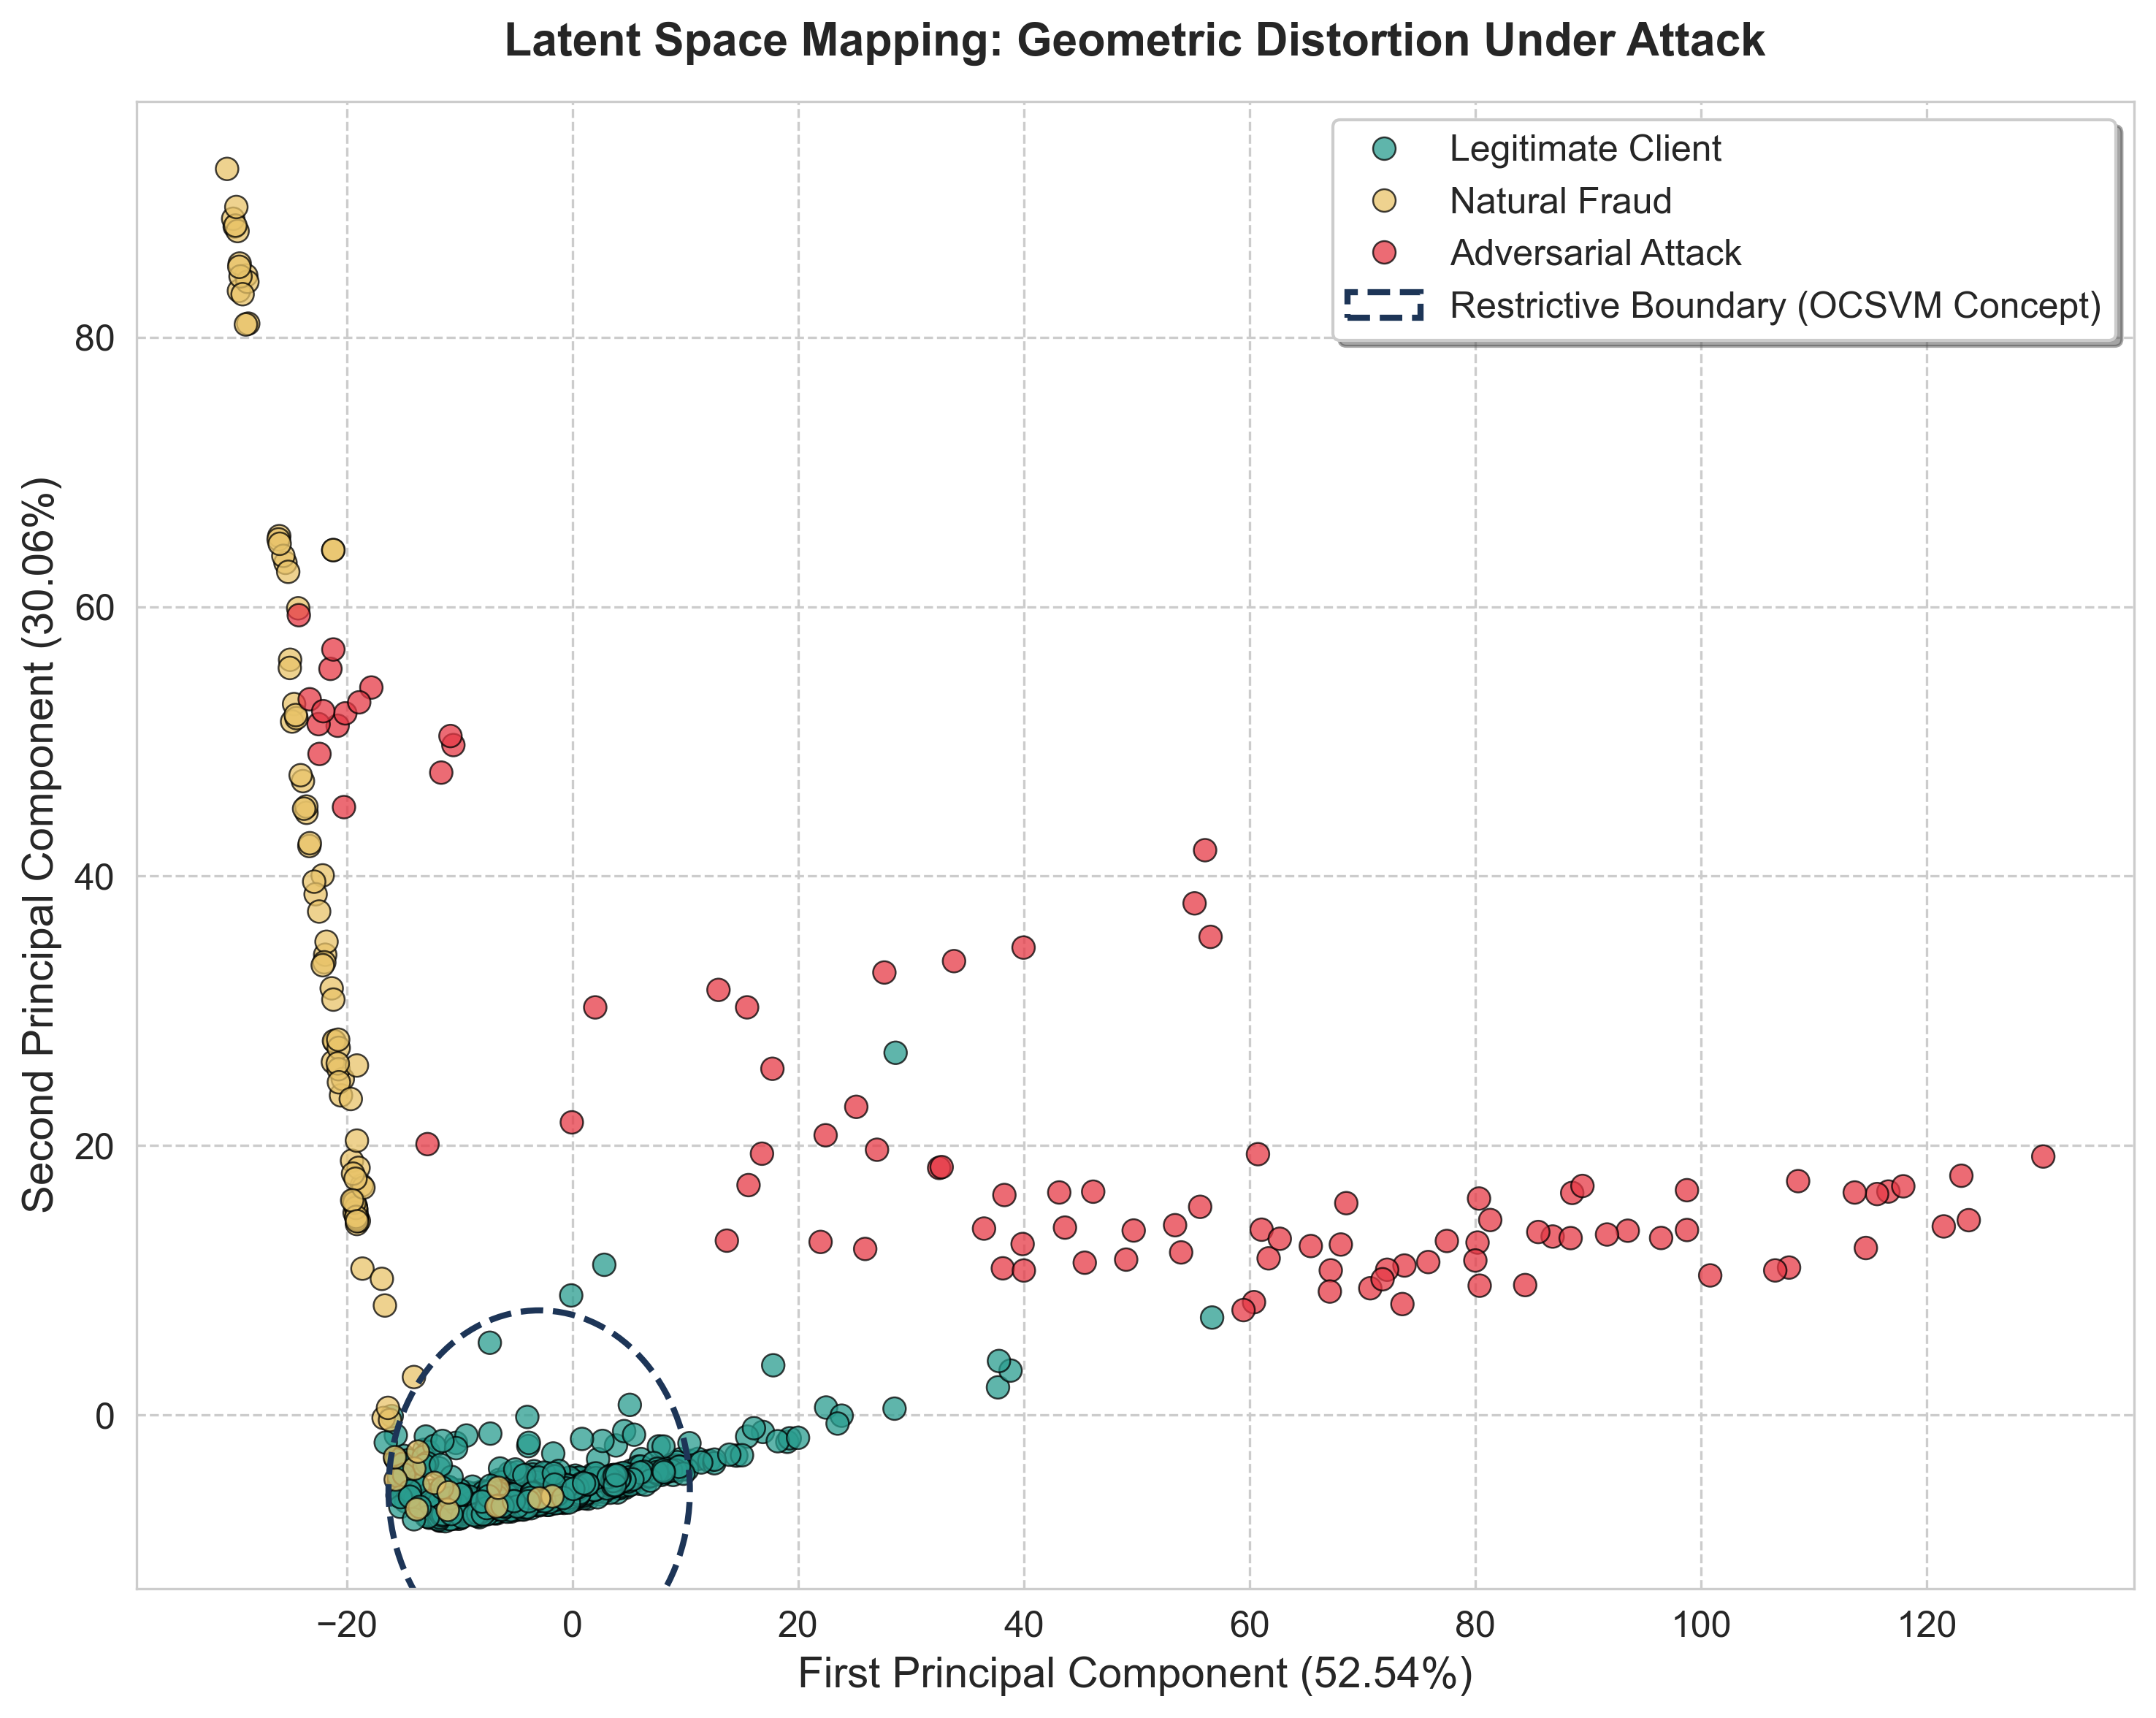

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
import torch

# ==========================================
# 🛑 SAFETY MEMORY CHECK (Prevents NameError)
# ==========================================
# If your notebook forgot the variables, we extract them dynamically from storage
if 'activation_storage' in globals() and activation_storage:
    if 'latents_natural_frauds' not in globals():
        latents_natural_frauds = activation_storage[1.0]['latents_clean']
    if 'latents_attacks' not in globals():
        epsilon_max = max(activation_storage.keys()) # Automatically gets 3.0
        latents_attacks = activation_storage[epsilon_max]['latents_adv']

if 'latents_honest' not in globals():
    # Fallback to extract 1000 honest clients activations dynamically if missing
    print("🔄 Dynamic recovery of honest latents for PCA...")
    indices_sains_val = np.where(y_val == 0)[0][:1000]
    X_honneta = X_val_tensor[indices_sains_val].to(device)
    model.eval()
    with torch.no_grad():
        act_honneta = model(X_honneta, extract_all_activations=True)
    latents_honest = torch.cat([act_honneta["layer1_128"], act_honneta["layer2_64"], act_honneta["layer3_32"]], dim=1)

# ==========================================
# MAIN GRAPH CODE
# ==========================================

# 1. Dynamic and safe conversion of pure activation tensors
honest_np = latents_honest.detach().cpu().numpy() if torch.is_tensor(latents_honest) else latents_honest
frauds_np = latents_natural_frauds.detach().cpu().numpy() if torch.is_tensor(latents_natural_frauds) else latents_natural_frauds
attacks_np = latents_attacks.detach().cpu().numpy() if torch.is_tensor(latents_attacks) else latents_attacks

total_space = np.vstack([honest_np, frauds_np, attacks_np])
categories = (['Legitimate Client'] * len(honest_np) + 
              ['Natural Fraud'] * len(frauds_np) + 
              ['Adversarial Attack'] * len(attacks_np))

# 2. 2D Projection computation
pca_engine = PCA(n_components=2, random_state=42)
coordinates_2d = pca_engine.fit_transform(total_space)

# 3. Multi-class scatter plot
plt.figure(figsize=(10, 8), dpi=300)
business_palette = {'Legitimate Client': '#2a9d8f', 'Natural Fraud': '#e9c46a', 'Adversarial Attack': '#e63946'}

sns.scatterplot(x=coordinates_2d[:, 0], y=coordinates_2d[:, 1], hue=categories, palette=business_palette,
                s=55, alpha=0.75, edgecolor='black', linewidth=0.6)

# Indicative geometric plot of normality envelope (OCSVM Hyper-sphere)
healthy_center = np.mean(coordinates_2d[:len(honest_np)], axis=0)
healthy_radius = np.std(coordinates_2d[:len(honest_np), 0]) * 1.95
hyper_sphere = plt.Circle(healthy_center, radius=healthy_radius, color='#1d3557', fill=False, linestyle='--', linewidth=2, label="Restrictive Boundary (OCSVM Concept)")
plt.gca().add_patch(hyper_sphere)

plt.title("Latent Space Mapping: Geometric Distortion Under Attack", fontweight='bold', pad=15)
plt.xlabel(f"First Principal Component ({pca_engine.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"Second Principal Component ({pca_engine.explained_variance_ratio_[1]*100:.2f}%)")
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.tight_layout()
plt.savefig("4_latent_space_boundary_pca.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\anita\AppData\Local\Temp\ipykernel_16484\1811300927.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Test Group', y='Connection Density (RBF Degree)', data=boxplot_dataset,


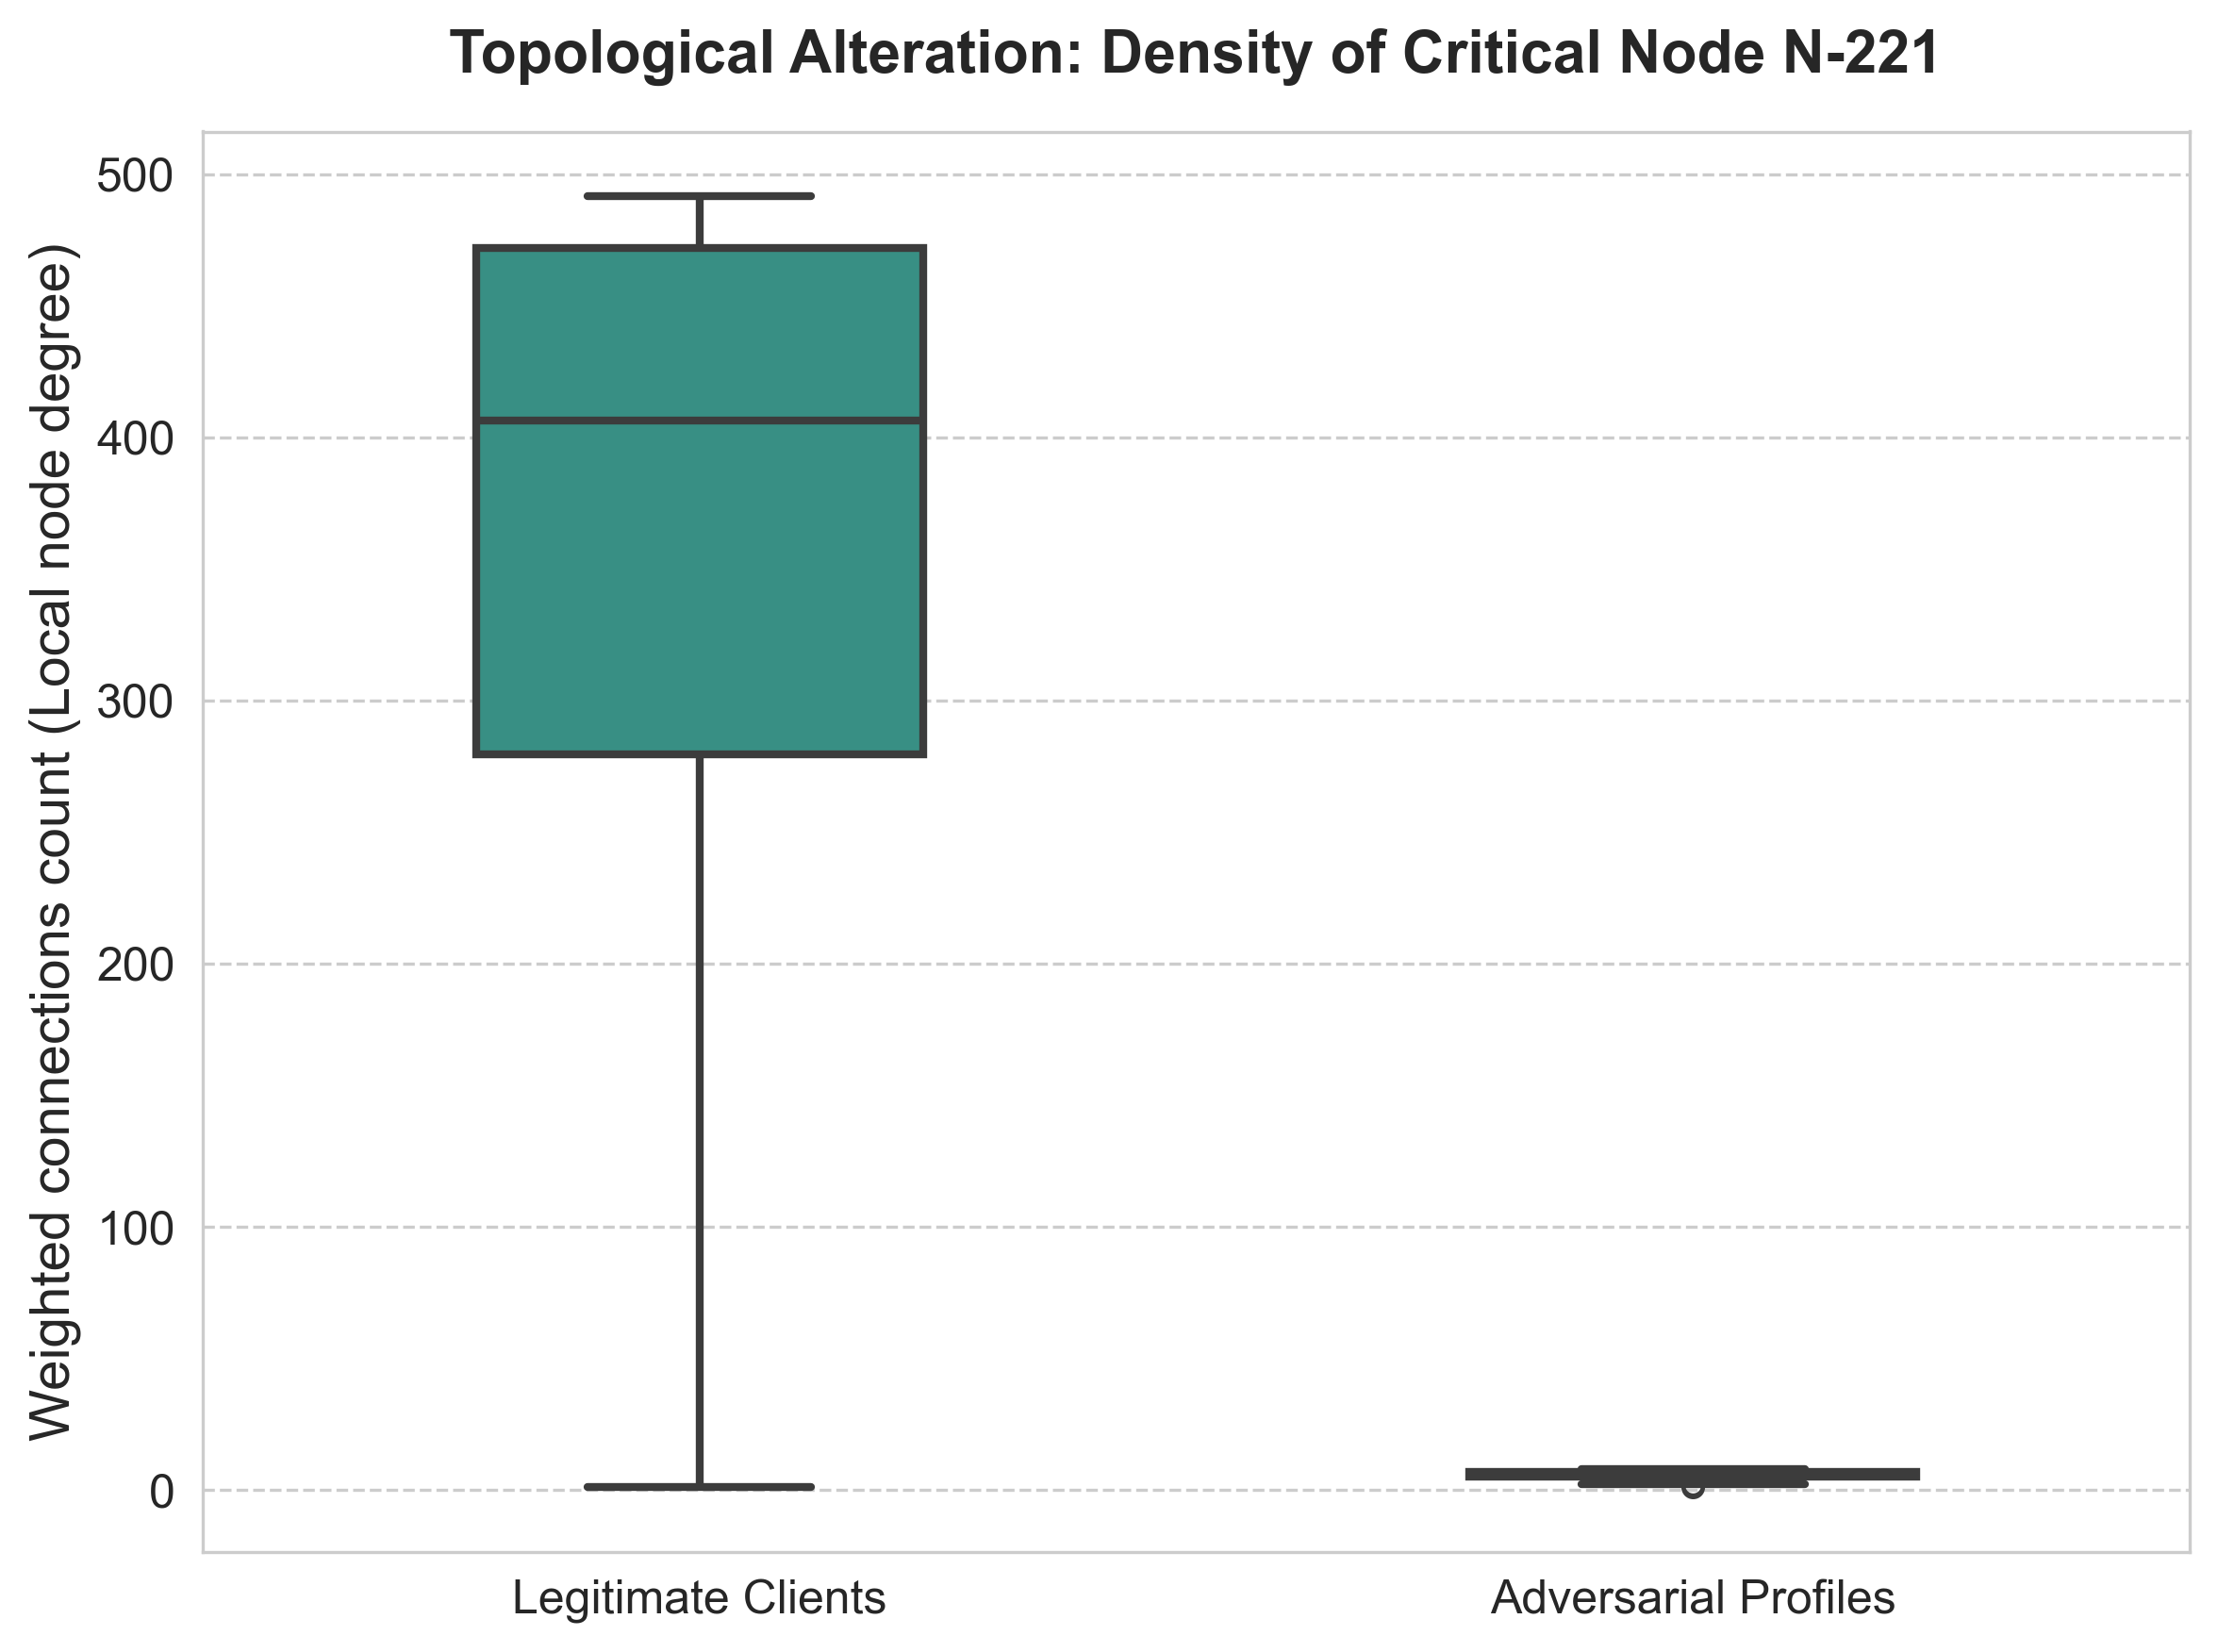

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pandas as pd
import numpy as np

# ==========================================
# 🛑 SAFETY MEMORY CHECK (Prevents NameError)
# ==========================================
# If your notebook forgot or didn't globally define the variables, we recover them dynamically
if 'activation_storage' in globals() and activation_storage:
    if 'latents_attacks' not in globals():
        epsilon_max = max(activation_storage.keys()) # Automatically targets 3.0
        latents_attacks = activation_storage[epsilon_max]['latents_adv']

if 'latents_honest' not in globals():
    print("🔄 Dynamic recovery of honest latents for Boxplot structure...")
    indices_sains_val = np.where(y_val == 0)[0][:1000]
    X_honneta = X_val_tensor[indices_sains_val].to(device)
    model.eval()
    with torch.no_grad():
        act_honneta = model(X_honneta, extract_all_activations=True)
    latents_honest = torch.cat([act_honneta["layer1_128"], act_honneta["layer2_64"], act_honneta["layer3_32"]], dim=1)

# ==========================================
# MAIN GRAPH CODE
# ==========================================

# 1. Extracting the most critical neuron (Rank 0)
neuron_index = ranked_all_nodes[0].item() if torch.is_tensor(ranked_all_nodes) else ranked_all_nodes[0]
gamma_rbf = 0.5

def extract_topological_degree(latent_tensors):
    # Isolation of the critical unit
    unit_activations = latent_tensors[:, neuron_index]
    # Computation of the local RBF similarity matrix
    distances = unit_activations.unsqueeze(1) - unit_activations.unsqueeze(0)
    S_rbf = torch.exp(-gamma_rbf * (distances ** 2))
    return S_rbf.sum(dim=1).detach().cpu().numpy()

# Dynamic computation on current populations
deg_l_healthy = extract_topological_degree(latents_honest)
deg_l_attacks = extract_topological_degree(latents_attacks)

# Assembling the analysis DataFrame
boxplot_dataset = pd.DataFrame({
    'Connection Density (RBF Degree)': np.concatenate([deg_l_healthy, deg_l_attacks]),
    'Test Group': ['Legitimate Clients'] * len(deg_l_healthy) + ['Adversarial Profiles'] * len(deg_l_attacks)
})

# 2. SOTA Boxplot Generation
plt.figure(figsize=(8, 6), dpi=300)
sns.boxplot(x='Test Group', y='Connection Density (RBF Degree)', data=boxplot_dataset,
            palette={'Legitimate Clients': '#2a9d8f', 'Adversarial Profiles': '#e63946'},
            width=0.45, linewidth=2, fliersize=5)

plt.title(f"Topological Alteration: Density of Critical Node N-{neuron_index}", fontweight='bold', pad=15)
plt.ylabel("Weighted connections count (Local node degree)")
plt.xlabel("")
plt.tight_layout()
plt.savefig("5_topological_impact_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

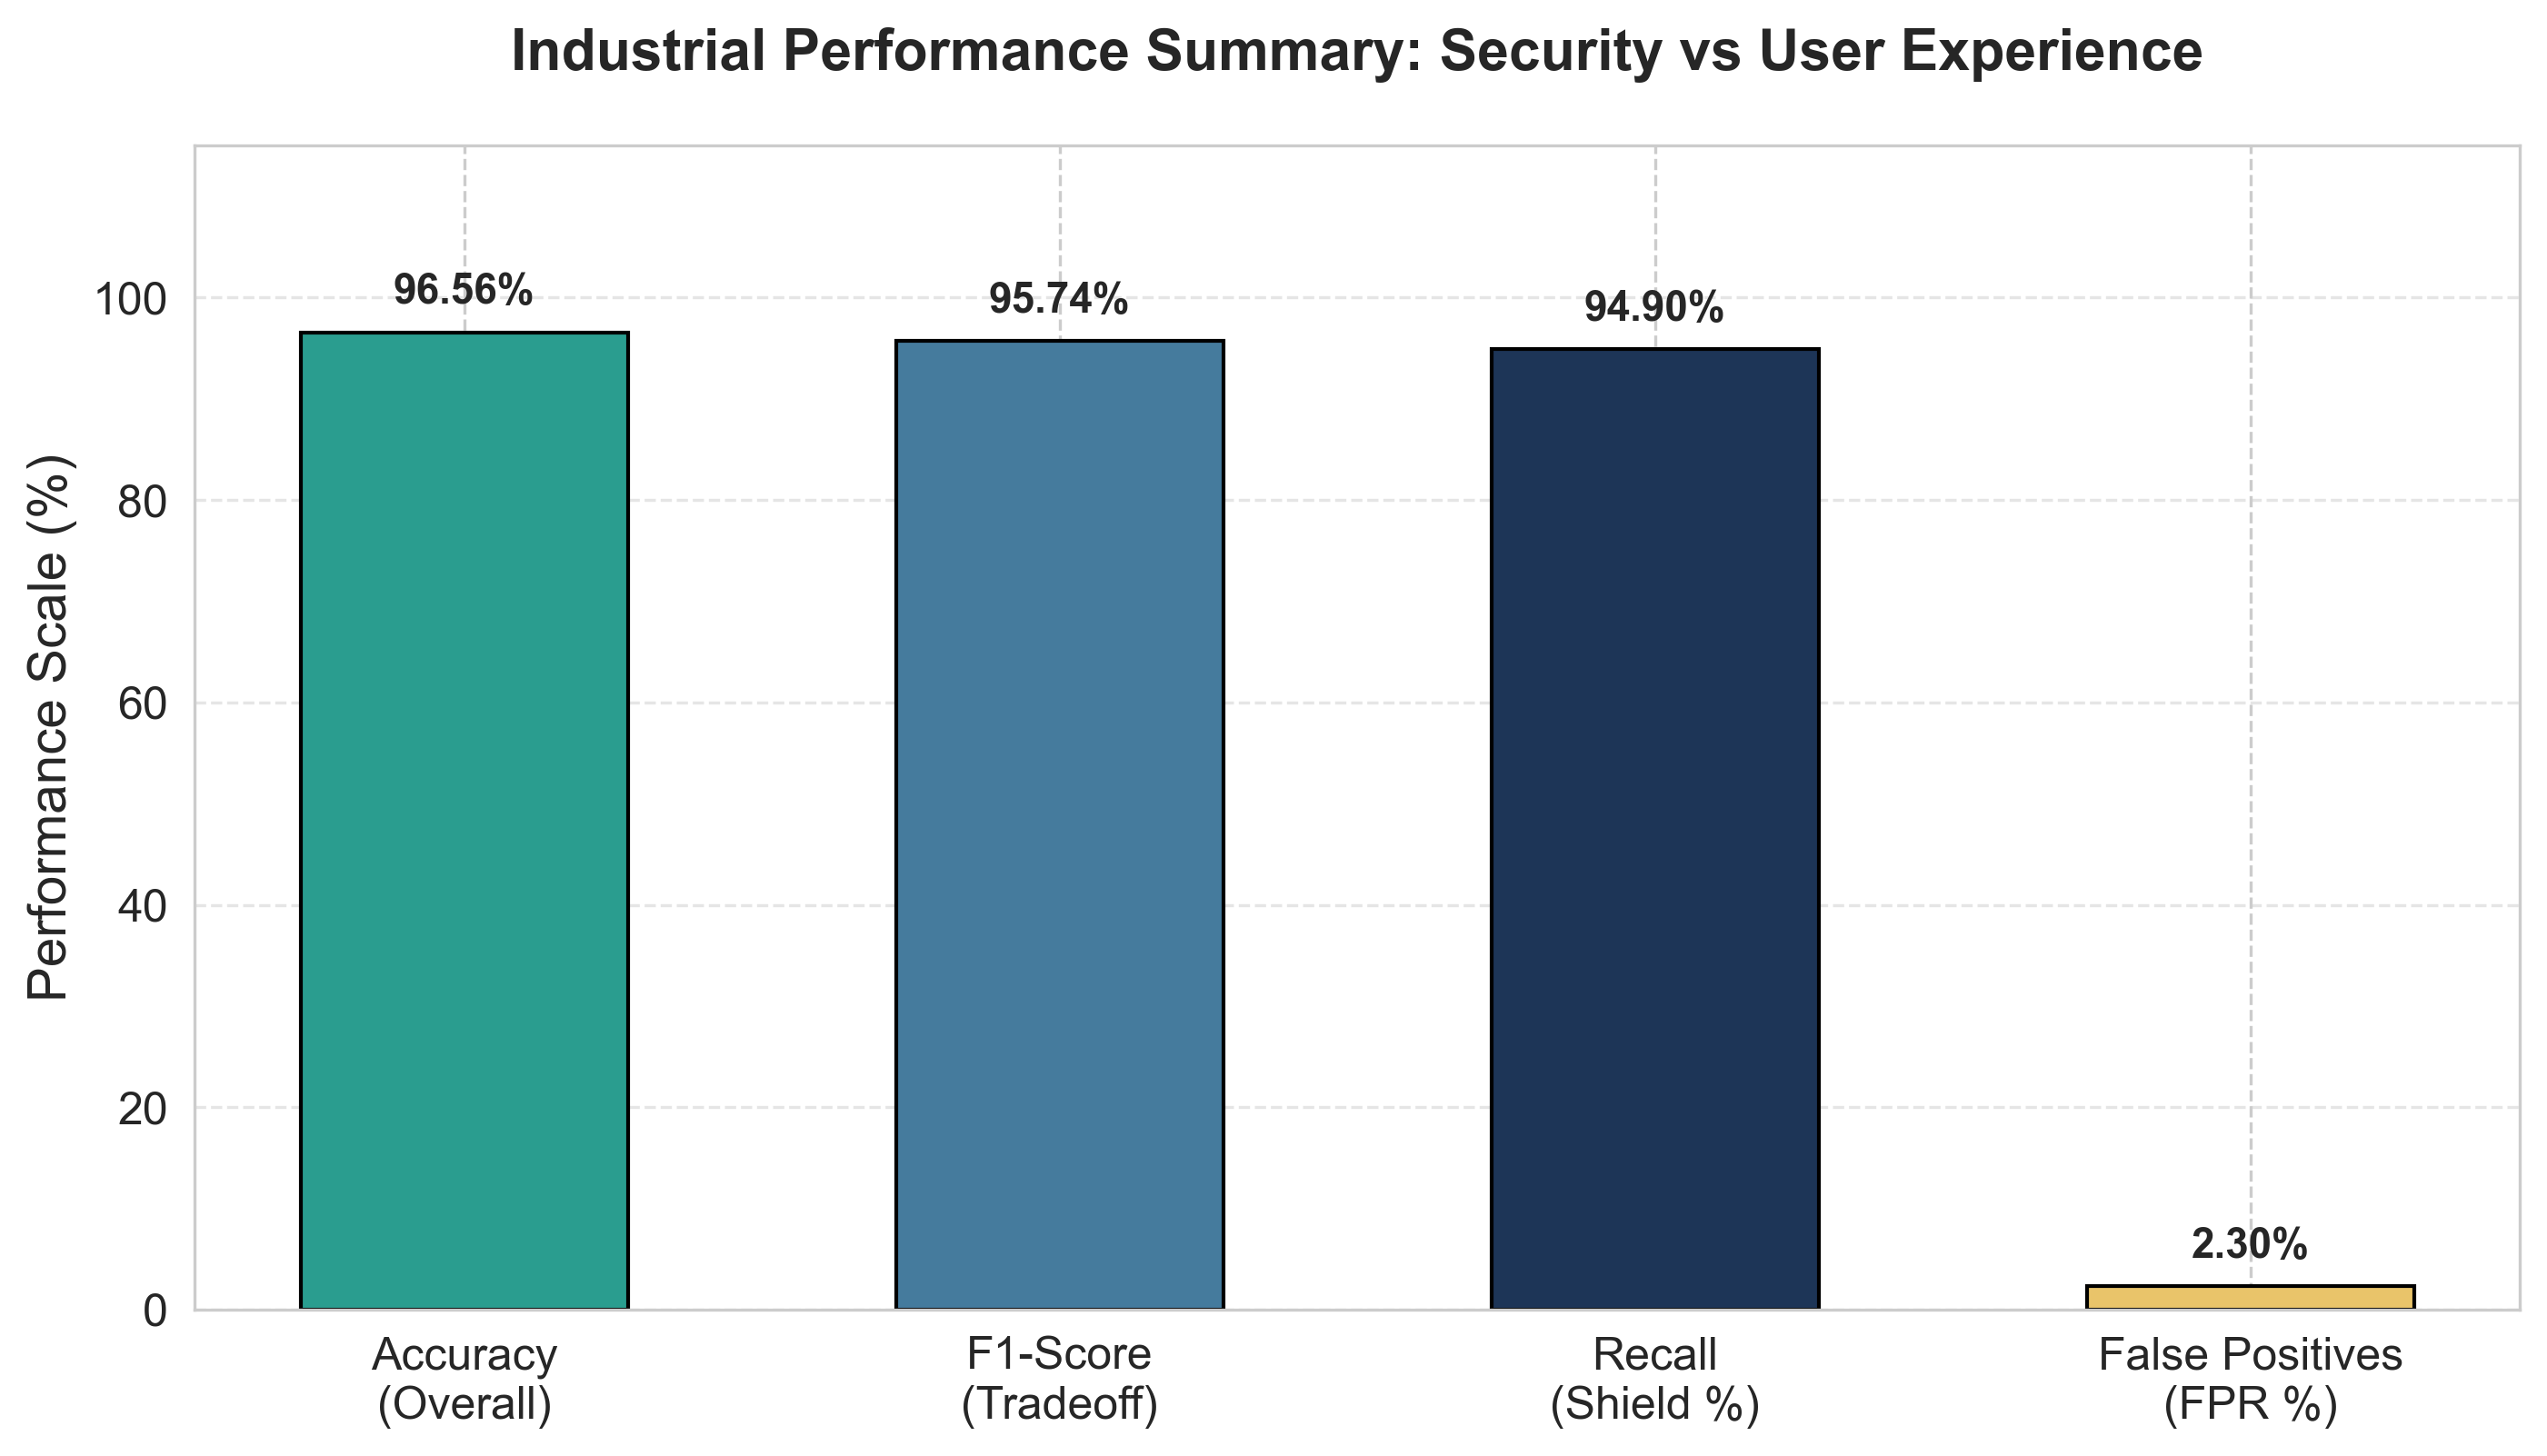

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Real-time computation of all current audit metrics
val_acc = accuracy_score(y_true_global, y_pred_global) * 100
val_f1 = f1_score(y_true_global, y_pred_global) * 100
val_rec = recall_score(y_true_global, y_pred_global) * 100

tn, fp, fn, tp = confusion_matrix(y_true_global, y_pred_global).ravel()
val_fpr = (fp / (fp + tn)) * 100

# Variables for display
indicators = ['Accuracy\n(Overall)', 'F1-Score\n(Tradeoff)', 'Recall\n(Shield %)', 'False Positives\n(FPR %)']
metric_values = [val_acc, val_f1, val_rec, val_fpr]
color_shades = ['#2a9d8f', '#457b9d', '#1d3557', '#e9c46a']

# 2. Synthesis graph generation
plt.figure(figsize=(9.5, 5.5), dpi=300)
graph_bars = plt.bar(indicators, metric_values, color=color_shades, edgecolor='black', linewidth=1, width=0.55)

for b in graph_bars:
    height = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, height + 2, f"{height:.2f}%", 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title("Industrial Performance Summary: Security vs User Experience", fontweight='bold', pad=20)
plt.ylabel("Performance Scale (%)")
plt.ylim(0, 115) 
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("6_performance_tradeoff_summary.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np

print("="*65)
print(" 🔬 HIGH-PRECISION AUDIT: STEALTH FRONTIER ")
print("="*65)
print("Epsilon | Hacker ASR (Naked ANN) | Committee Interception")
print("-" * 65)

# Specifically targeting very low epsilons up to 1.0
stealth_epsilons = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

for eps in stealth_epsilons:
    # Check if the data exists in the dictionary
    if eps in activation_storage:
        
        # 1. Attack Success Rate on the ANN (Hacker ASR)
        asr = activation_storage[eps]['ASR']
        
        # 2. Retrieve the distorted latent space
        adv_latents = activation_storage[eps]['latents_adv']
        
        # 3. The topological Committee delivers its verdict
        # vote_rule=2 means at least 2 out of 3 experts must raise an alert
        defense_preds = predict_committee(adv_latents, vote_rule=2)
        
        # Calculate the percentage of blocked attacks
        interception_rate = (np.sum(defense_preds) / len(defense_preds)) * 100
        
        # Formatted output
        print(f"  {eps:.1f}   |       {asr:5.2f} %       |          {interception_rate:6.2f} %")
        
    else:
        print(f"  {eps:.1f}   | Not computed in the initial dictionary.")

print("="*65)